###  Export data from hdf5 files to pandas dataframes for statistical analysis
- Load HDF5 → structured tables
- Aggregate → patient + stage level
- Clean → remove invalid values
- Run statistics later

In [2]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.stats import mannwhitneyu, shapiro, ttest_ind

candidate_base_dirs = [Path.cwd(), *Path.cwd().parents]
base_dir = next((p for p in candidate_base_dirs if (p / "HDF files").exists()), Path.cwd())
hdf_dir = base_dir / "HDF files"
results_dir = base_dir / "Notebooks"

group_order = ["control", "rbd"]
stage_order = ["Wake", "N1", "N2", "N3", "REM"]
palette = {"control": "#4C78A8", "rbd": "#E45756"}
ci_level = 0.95
ci_resamples = 10000
ci_random_seed = 42

sns.set_theme(style="whitegrid", context="notebook")
print(f"Using HDF folder: {hdf_dir}")


def read_value(node):
    # Reads a value from an HDF5 node
    value = node[()]
    if isinstance(value, bytes): # If value is stored as bytes, decode to string
        return value.decode("utf-8")
    if isinstance(value, np.generic): #  If value is a NumPy scalar ( np.float64), convert to Python scalar
        return value.item()
    return value


def maybe_read(group, key):
    # Reads a value from the group if the key exists, otherwise returns NaN
    return read_value(group[key]) if key in group else np.nan


def load_h5_summaries(hdf_dir: Path):
    patient_rows = [] # store one row per patient with patient-level summary statistics
    epoch_rows = [] # store one row per epoch with epoch-level statistics, including sleep stage and bandpower

    for h5_path in sorted(hdf_dir.glob("*.h5")):
        # Loop through all .h5 files
        try:
            with h5py.File(h5_path, "r") as f:
                if len(f.keys()) == 0: # Skip empty files
                    print(f"Skipping empty file: {h5_path.name}")
                    continue

                patient_id = next(iter(f.keys()))  # Each file has one patient
                patient = f[patient_id]

                # Read group (control / rbd)
                group = str(patient.attrs.get("group", "unknown")).lower()

                # !! PATIENT-LEVEL FEATURES !!
                patient_row = {
                    "patient_id": patient_id,
                    "group": group,

                    # Data quality / counts
                    "n_epochs_all": maybe_read(patient, "n_epochs_all"),
                    "n_epochs_rem": maybe_read(patient, "n_epochs_rem"),
                    "n_epochs_nrem": maybe_read(patient, "n_epochs_nrem"),
                    "n_valid_hep_epochs": maybe_read(patient, "n_valid_hep_epochs"),

                    # Global averages
                    "mean_delta_power_all": maybe_read(patient, "mean_delta_power_all"),
                    "mean_delta_power_REM": maybe_read(patient, "mean_delta_power_REM"),
                    "mean_delta_power_NREM": maybe_read(patient, "mean_delta_power_NREM"),
                    "mean_hep_all": maybe_read(patient, "mean_hep_all"),
                    "mean_hep_REM": maybe_read(patient, "mean_hep_REM"),
                    "mean_hep_NREM": maybe_read(patient, "mean_hep_NREM"),
                }

                # !! HEP waveform-derived features !!
                if "hep_waveform_derived" in patient:
                    wf = patient["hep_waveform_derived"]
                    for key in [
                        "hep_peak_latency_all",
                        "hep_peak_latency_REM",
                        "hep_peak_latency_NREM",
                        "hep_auc_all",
                        "hep_auc_REM",
                        "hep_auc_NREM",
                    ]:
                        patient_row[key] = maybe_read(wf, key)

                # !! Correlation features !!
                if "correlations" in patient:
                    corr = patient["correlations"]
                    for key in corr.keys():
                        patient_row[key] = read_value(corr[key])

                patient_rows.append(patient_row)

                # !! EPOCH-LEVEL FEATURES !!
                if "epochs" not in patient:
                    continue

                for epoch_name, epoch in patient["epochs"].items():
                    epoch_rows.append(
                        {
                            "patient_id": patient_id,
                            "group": group,
                            "epoch": epoch_name,
                            # Sleep stage
                            "stage": read_value(epoch["sleep_stage"]),

                            # EEG bandpower
                            "delta": read_value(epoch["eeg_bandpower"]["delta"]),
                            "theta": read_value(epoch["eeg_bandpower"]["theta"]),
                            "alpha": read_value(epoch["eeg_bandpower"]["alpha"]),
                            "beta": read_value(epoch["eeg_bandpower"]["beta"]),
                            "gamma": read_value(epoch["eeg_bandpower"]["gamma"]),

                            # HRV
                            "hr_mean_bpm": read_value(epoch["hrv"]["hr_mean_bpm"]),
                            "rmssd_ms": read_value(epoch["hrv"]["rmssd_ms"]),
                            "sdnn_ms": read_value(epoch["hrv"]["sdnn_ms"]),
                            "pnn50_pct": read_value(epoch["hrv"]["pnn50_pct"]),

                            # CPC
                            "hfc": read_value(epoch["cpc"]["hfc"]),
                            "lfc": read_value(epoch["cpc"]["lfc"]),
                            "cpc_ratio": read_value(epoch["cpc"]["ratio"]),

                            # HEP
                            "pearson_1s_r": read_value(epoch["hep"]["pearson_1s_r"]),
                            "spearman_1s_r": read_value(epoch["hep"]["spearman_1s_r"]),
                            "hep_30s": read_value(epoch["hep"]["hep_30s"]),
                            "delta_30s": read_value(epoch["hep"]["delta_30s"]),
                        }
                    )
        except OSError as exc:
            print(f"Skipping {h5_path.name}: {exc}")

    # create dataframes from the collected rows
    patient_df = pd.DataFrame(patient_rows)
    epoch_df = pd.DataFrame(epoch_rows)

    if not patient_df.empty:
        patient_df = patient_df.sort_values(["group", "patient_id"]).reset_index(drop=True)

    if not epoch_df.empty:
        epoch_df["stage"] = pd.Categorical(epoch_df["stage"], categories=stage_order, ordered=True)
        # Define numeric columns for stage-level averaging !!
        numeric_cols = [
            "delta",
            "theta",
            "alpha",
            "beta",
            "gamma",
            "hr_mean_bpm",
            "rmssd_ms",
            "sdnn_ms",
            "pnn50_pct",
            "hfc",
            "lfc",
            "cpc_ratio",
            "pearson_1s_r",
            "spearman_1s_r",
            "hep_30s",
            "delta_30s",
        ]
        # Compute stage-level averages for each patient and group 
        # for each patient does the stage-level average across all epochs of that stage
        # then for each group does the average across patients of that stage-level average
        stage_df = (
            epoch_df.groupby(["patient_id", "group", "stage"], observed=True)[numeric_cols]
            .mean(numeric_only=True)
            .reset_index()
        )
    else:
        stage_df = pd.DataFrame()

    return patient_df, stage_df, epoch_df


def finite_values(values):
    # Convert to float array
    values = np.asarray(values, dtype=float)
    # Remove NaN and infinite values
    return values[np.isfinite(values)]

Using HDF folder: c:\Users\carlo\OneDrive - Universidade de Lisboa\Documents\GitHub\heart-lung-brain-coupling-for-RBD\HDF files


### Statistics module for heart-lung-brain coupling in RBD study

In [3]:

# Report robust 95% bootstrap confidence intervals alongside the hypothesis tests.
# This provides a more complete picture of the data, especially with small samples and non-normal distributions.

def bootstrap_ci(values, stat_fn=np.mean, confidence=ci_level, n_resamples=ci_resamples, random_seed=ci_random_seed):
    # estimates a confidence interval for one group
    # resample the group many times 
    # computes mean each time 
    # distribution of those means to estimate the 95% CI
    # Clean the input values to ensure we only work with finite numbers
    values = finite_values(values)
    # If there is no valid data, return missing CI
    if values.size == 0:
        return np.nan, np.nan

    # Create a random number generator for reproducibility
    rng = np.random.default_rng(random_seed)
    
    # Generate bootstrap samples:
    # shape = (number of resamples, sample size)
    # sampling is done WITH replacement to mimic the original sampling process
    samples = rng.choice(values, size=(n_resamples, values.size), replace=True)

    # Compute the statistic of interest for each bootstrap sample
    # default = mean
    stats = stat_fn(samples, axis=1)
    # Compute lower and upper quantiles for the confidence interval
    alpha = (1 - confidence) / 2
    low, high = np.quantile(stats, [alpha, 1 - alpha])
    # Return CI as plain Python floats for better readability in tables
    return float(low), float(high)


def bootstrap_mean_difference_ci(x, y, confidence=ci_level, n_resamples=ci_resamples, random_seed=ci_random_seed):
    # estimates the difference between groups 
    # resample each group many times
    # compute the mean for each resample
    # distribution of those mean differences to estimate the 95% CI
    # to compare means between control and rbd groups

    # Keep only valid values in each group
    x = finite_values(x)
    y = finite_values(y)
    if x.size == 0 or y.size == 0: # If one group has no data, return missing CI
        return np.nan, np.nan
    
    # Random generator for reproducibility
    rng = np.random.default_rng(random_seed)

    # Bootstrap resampling for each group independently
    x_samples = rng.choice(x, size=(n_resamples, x.size), replace=True)
    y_samples = rng.choice(y, size=(n_resamples, y.size), replace=True)
    # Compute difference in means for each bootstrap resample
    diffs = x_samples.mean(axis=1) - y_samples.mean(axis=1)
    # Compute quantiles for the confidence interval
    alpha = (1 - confidence) / 2
    low, high = np.quantile(diffs, [alpha, 1 - alpha])
    return float(low), float(high)


def cohen_d(x, y):
    # Compute Cohen's d for effect size, using pooled standard deviation
    # Cohen’s d, which is the effect size for t-tests
    # quantify the magnitude of the difference between two means
    #  While statistical significance (like a -value) tells you if a difference exists, Cohen's tells you how large or practically meaningful that difference is
    # 0.2 = small effect. 0.5 = moderate effect. 0.8 = large effect

    # Keep only valid values in each group
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    # Number of observations in each group
    nx = len(x)
    ny = len(y)
    
    # Need at least 2 observations per group
    if nx < 2 or ny < 2:
        return np.nan

    # Sample standard deviations for each group
    sx = np.nanstd(x, ddof=1)
    sy = np.nanstd(y, ddof=1)

    # Pooled standard deviation for Cohen's d
    # Unequal Group Sizes: A weighted average is used to give more importance to the larger group
    pooled = np.sqrt(((nx - 1) * sx**2 + (ny - 1) * sy**2) / (nx + ny - 2))

    if pooled == 0 or not np.isfinite(pooled): # Avoid division by zero or invalid values
        return np.nan

    # Cohen's d = difference in means / pooled SD
    # If it is negative ---> control mean < RBD mean
    # If it is positive --> control mean > RBD mean
    return (np.nanmean(x) - np.nanmean(y)) / pooled


def rank_biserial_from_u(u_stat, n1, n2):
    # u_stat = Mann-Whitney U statistic
    # n1 = size of group 1 (e.g., control)
    # n2 = size of group 2 (e.g., rbd)

    # The rank-biserial correlation is a non-parametric measure of association used to determine the relationship between a dichotomous (binary) variable and an ordinal (ranked) variable. 
    # It is commonly used as an effect size for the Mann-Whitney U test
    # measures the strength and direction of the relationship when data does not meet the assumptions of normality.
    # The coefficient typically ranges from -1 to +1
    # If one group is empty, effect size cannot be computed
    if n1 == 0 or n2 == 0:
        return np.nan
    # Convert Mann-Whitney U statistic into rank-biserial correlation
    return 1 - (2 * u_stat) / (n1 * n2)


def benjamini_hochberg(p_values):
    # control the false discovery rate (FDR) when performing multiple hypothesis tests
    # ranks the p-values from smallest to largest, then adjusts them based on their rank and the total number of tests
    # is the final corrected p-value

    # Convert p-values to float array
    p_values = np.asarray(p_values, dtype=float)
    # Initialize output with NaN
    adjusted = np.full_like(p_values, np.nan, dtype=float)
    # Identify which p-values are valid numbers
    finite = np.isfinite(p_values)
     # If none are valid, return all NaN
    if not finite.any():
        return adjusted

    p = p_values[finite] # Work only on valid p-values
    order = np.argsort(p) # Sort p-values
    ranked = p[order]
    n = len(ranked)

    # Benjamini-Hochberg adjustment
    q = ranked * n / np.arange(1, n + 1)
    # Enforce monotonicity from the end
    q = np.minimum.accumulate(q[::-1])[::-1]
    # Keep adjusted values between 0 and 1
    q = np.clip(q, 0, 1)

    # Put adjusted p-values back in original order
    adjusted_finite = np.empty_like(p)
    adjusted_finite[order] = q
    adjusted[finite] = adjusted_finite
    return adjusted


def compare_groups(df, metric, group_col="group"):
    # Compare control vs rbd for a given metric, returning a dictionary of results 
    # including means, confidence intervals, test statistics, p-values, and effect sizes

    # Keep only the group column and the metric of interest
    # Remove rows with missing values
    subset = df[[group_col, metric]].dropna().copy()

    # Separate the metric values by group
    control = subset.loc[subset[group_col] == "control", metric].astype(float)
    rbd = subset.loc[subset[group_col] == "rbd", metric].astype(float)

    # Bootstrap confidence intervals for each group mean
    control_ci_low, control_ci_high = bootstrap_ci(control)
    rbd_ci_low, rbd_ci_high = bootstrap_ci(rbd)
    mean_diff = control.mean() - rbd.mean()

    # Bootstrap CI for difference in means
    mean_diff_ci_low, mean_diff_ci_high = bootstrap_mean_difference_ci(control, rbd)

    row = {
        "metric": metric,
        "n_control": int(control.shape[0]),
        "n_rbd": int(rbd.shape[0]),
        
        "mean_control": control.mean(),
        "mean_control_ci_low": control_ci_low,
        "mean_control_ci_high": control_ci_high,

        "mean_rbd": rbd.mean(),
        "mean_rbd_ci_low": rbd_ci_low,
        "mean_rbd_ci_high": rbd_ci_high,

        "mean_diff_control_minus_rbd": mean_diff,
        "mean_diff_ci_low": mean_diff_ci_low,
        "mean_diff_ci_high": mean_diff_ci_high,

        "median_control": control.median(),
        "median_rbd": rbd.median(),
        "sd_control": control.std(ddof=1),
        "sd_rbd": rbd.std(ddof=1),
    }

    # If sample size is too small, stop here
    if len(control) < 3 or len(rbd) < 3:
        row.update(
            {
                "test": "insufficient_n",
                "statistic": np.nan,
                "p_value": np.nan,
                "effect_size": np.nan,
                "effect_name": np.nan,
                "shapiro_control_p": np.nan,
                "shapiro_rbd_p": np.nan,
            }
        )
        return row

    # statistical hypothesis test used to determine if a data sample follows a normal distribution
    # H0 = data is normally distributed
    # H1 = data is not normally distributed
    # A value close to 1 indicates the data is consistent with a normal distribution.
    shapiro_control_p = shapiro(control).pvalue
    shapiro_rbd_p = shapiro(rbd).pvalue
    use_t_test = (shapiro_control_p > 0.05) and (shapiro_rbd_p > 0.05)
    # p > 0.05 → data looks normal
    # p < 0.05 → data does NOT look normal

    # if data looks like a bell-curve -> t-test 
    # if data looks skewed or has outliers -> Mann-Whitney U test (non-parametric)

    if use_t_test:
        # If both groups are normally distributed, use Welch's t-test which does not assume equal variances
        # Welch's t-test is a more robust version of the Student's t-test that does not assume equal variances between groups
        stat, p_value = ttest_ind(control, rbd, equal_var=False, nan_policy="omit")
        effect_size = cohen_d(control, rbd)
        effect_name = "cohen_d" # Cohen’s d, which is the effect size for t-tests
        test_name = "welch_t"
    else:
        # If either group is not normally distributed, use Mann-Whitney U test which is non-parametric and does not assume normality
        # Mann-Whitney U test is a non-parametric test that compares the distributions of two independent groups without assuming normality

        stat, p_value = mannwhitneyu(control, rbd, alternative="two-sided")
        effect_size = rank_biserial_from_u(stat, len(control), len(rbd))
        effect_name = "rank_biserial" # rank-biserial correlation, which is an effect size for the Mann-Whitney U test
        test_name = "mann_whitney"

    row.update(
        {
            "test": test_name,
            "statistic": stat,
            "p_value": p_value,
            "effect_size": effect_size,
            "effect_name": effect_name,
            "shapiro_control_p": shapiro_control_p,
            "shapiro_rbd_p": shapiro_rbd_p,
        }
    )
    return row


def run_stats_table(df, metrics, group_col="group"):
    # Run group comparisons for a list of metrics and return a dataframe with results, including FDR-corrected p-values
     # Each call to compare_groups(...) returns one dictionary / one result row

    stats_df = pd.DataFrame(compare_groups(df, metric, group_col=group_col) for metric in metrics)

    # Apply Benjamini-Hochberg correction to all raw p-values
    # This controls for multiple comparisons
    stats_df["p_fdr_bh"] = benjamini_hochberg(stats_df["p_value"].to_numpy(dtype=float))

    # Sort results by raw p-value (smallest first)
    # Put NaN p-values at the end
    return stats_df.sort_values("p_value", na_position="last").reset_index(drop=True)


def stage_stats_table(stage_df, metric):
    # Run group comparisons for a given metric across sleep stage
    # returning a dataframe with results for each stage, including FDR-corrected p-values
    # Store one result row per sleep stage
    rows = []
    # Loop through all sleep stages in the predefined order
    for stage in stage_order:
        # Keep only rows from this stage
        stage_subset = stage_df.loc[stage_df["stage"] == stage].copy()
        # Skip if there is no data for this stage
        if stage_subset.empty:
            continue
        # Compare control vs RBD for this metric within this stage
        row = compare_groups(stage_subset, metric)
        row["stage"] = stage # Add the stage name to the result row
        rows.append(row)

    stats_df = pd.DataFrame(rows) # Convert all rows into a DataFrame
    if not stats_df.empty:
        stats_df["p_fdr_bh"] = benjamini_hochberg(stats_df["p_value"].to_numpy(dtype=float)) # Apply multiple-comparison correction across stages
    return stats_df


def plot_metric(df, metric, title=None, ylabel=None, group_col="group"):
    # Keep only the group column and the metric column
    # Remove missing values
    plot_df = df[[group_col, metric]].dropna().copy()
    if plot_df.empty:
        print(f"No data available for {metric}")   # If no valid data exists, stop
        return

    # Compute the group comparison results for this metric
    # This is only used to display the test name, p-value, and effect size on the plot title
    stats_row = compare_groups(df, metric, group_col=group_col)

    # Draw boxplot for each group
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=plot_df, x=group_col, y=metric, order=group_order, palette=palette, showfliers=False, width=0.5)
    # Overlay individual data points
    sns.stripplot(data=plot_df, x=group_col, y=metric, order=group_order, color="black", alpha=0.7, jitter=0.12, size=6)
    plt.title(title or metric)
    plt.xlabel("")
    plt.ylabel(ylabel or metric)
    plt.grid(axis="y", alpha=0.25)

    if pd.notna(stats_row["p_value"]):
        plt.suptitle(
            f"{stats_row['test']} | p={stats_row['p_value']:.3g} | effect={stats_row['effect_size']:.3g}",
            y=0.98,
            fontsize=10,
        )

    plt.tight_layout()
    plt.show()


def plot_stage_metric(stage_df, metric, title=None, ylabel=None):
    # Keep only needed columns and remove missing values
    plot_df = stage_df[["patient_id", "group", "stage", metric]].dropna().copy()
    if plot_df.empty: 
        print(f"No stage data available for {metric}") #If no valid data exists, stop
        return

    ax = plt.figure(figsize=(10, 4)).gca()
    # Draw boxplots by sleep stage, separated by group
    sns.boxplot(data=plot_df, x="stage", y=metric, hue="group", order=stage_order, hue_order=group_order, palette=palette, showfliers=False, ax=ax)
    sns.stripplot(data=plot_df, x="stage", y=metric, hue="group", order=stage_order, hue_order=group_order, dodge=True, alpha=0.5, color="black", size=4, ax=ax)
    handles, labels = ax.get_legend_handles_labels() # Fix duplicated legend caused by boxplot + stripplot
    ax.legend(handles[: len(group_order)], labels[: len(group_order)], title="group", bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.set_title(title or f"{metric} by stage")
    ax.set_xlabel("Sleep stage")
    ax.set_ylabel(ylabel or metric)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

Patients loaded: 30
group
control    15
rbd        15
Name: count, dtype: int64


,patient_id,group,n_epochs_all,n_valid_hep_epochs
0,ins1,control,906,906
1,ins2,control,1675,1675
2,ins3,control,856,856
3,ins4,control,718,718
4,ins5,control,1720,1716
5,ins6,control,1057,1057
6,ins7,control,1483,1482
7,ins8,control,833,833
8,ins9,control,1050,1050
9,n01,control,1140,1139


,metric,n_control,n_rbd,mean_control,mean_control_ci_low,mean_control_ci_high,mean_rbd,mean_rbd_ci_low,mean_rbd_ci_high,mean_diff_control_minus_rbd,...,sd_control,sd_rbd,test,statistic,p_value,effect_size,effect_name,shapiro_control_p,shapiro_rbd_p,p_fdr_bh
0,mean_hep_NREM,15,15,3.4877,2.8810,4.1992,2.8049,1.9296,4.2152,0.6827,...,1.3601,2.5241,mann_whitney,172.0000,0.0144,-0.5289,rank_biserial,0.0224,0.0000,0.1529
1,mean_hep_all,15,15,3.5905,2.9952,4.2826,2.8584,1.9895,4.2188,0.7321,...,1.3168,2.4414,mann_whitney,171.0000,0.0161,-0.5200,rank_biserial,0.0367,0.0000,0.1529
2,spearman_30s_r_all,15,15,0.3148,0.2361,0.3912,0.1748,0.0931,0.2458,0.1399,...,0.1561,0.1582,welch_t,2.4389,0.0213,0.8906,cohen_d,0.2434,0.0813,0.1529
3,mean_hep_REM,15,15,3.1398,2.4896,3.8874,2.5382,1.6811,3.9392,0.6016,...,1.4387,2.5351,mann_whitney,167.0000,0.0251,-0.4844,rank_biserial,0.0134,0.0000,0.1529
4,spearman_30s_r_NREM,15,15,0.3226,0.2332,0.4021,0.1779,0.0936,0.2605,0.1447,...,0.1711,0.1692,welch_t,2.3289,0.0273,0.8504,cohen_d,0.1123,0.9860,0.1529
5,spearman_30s_p_NREM,15,15,0.0406,0.0000,0.1035,0.1641,0.0089,0.3461,-0.1235,...,0.1077,0.3387,mann_whitney,63.0000,0.0421,0.4400,rank_biserial,0.0000,0.0000,0.1965
6,spearman_30s_p_all,15,15,0.0066,0.0000,0.0197,0.0010,0.0000,0.0030,0.0056,...,0.0249,0.0039,mann_whitney,67.0000,0.0620,0.4044,rank_biserial,0.0000,0.0000,0.2479
7,mean_delta_power_all,15,15,0.4224,0.3807,0.4675,0.3731,0.3251,0.4230,0.0493,...,0.0898,0.0992,welch_t,1.4266,0.1649,0.5209,cohen_d,0.5380,0.9241,0.5157
8,pearson_30s_r_all,15,15,0.2465,0.1677,0.3272,0.1699,0.0988,0.2338,0.0765,...,0.1620,0.1399,welch_t,1.3849,0.1773,0.5057,cohen_d,0.5813,0.3491,0.5157
9,hep_peak_latency_NREM,15,15,0.2359,0.1526,0.3249,0.1273,0.0639,0.1957,0.1086,...,0.1799,0.1365,mann_whitney,145.0000,0.1842,-0.2889,rank_biserial,0.0392,0.0078,0.5157


Saved: c:\Users\carlo\OneDrive - Universidade de Lisboa\Documents\GitHub\heart-lung-brain-coupling-for-RBD\Notebooks\statistics_patient_level_results.csv


C:\Users\carlo\AppData\Local\Temp\ipykernel_11884\1060146072.py:298: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=group_col, y=metric, order=group_order, palette=palette, showfliers=False, width=0.5)


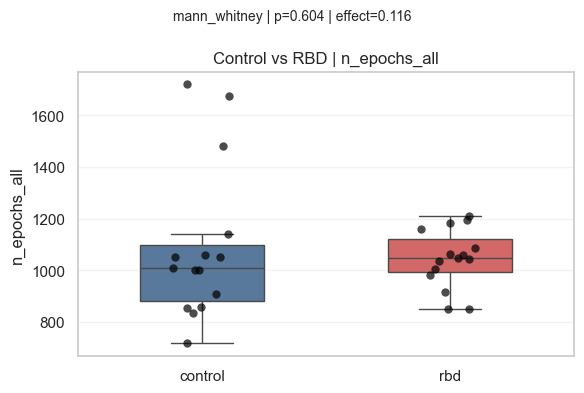

C:\Users\carlo\AppData\Local\Temp\ipykernel_11884\1060146072.py:298: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=group_col, y=metric, order=group_order, palette=palette, showfliers=False, width=0.5)


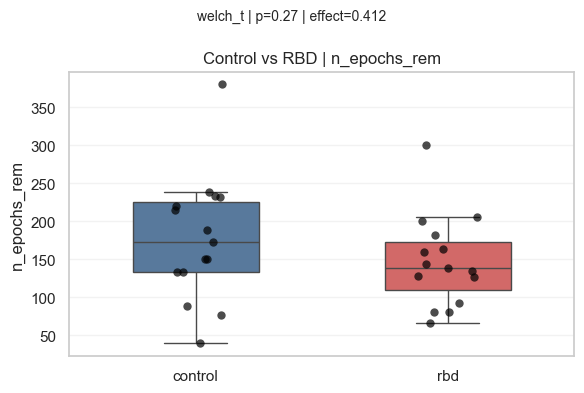

C:\Users\carlo\AppData\Local\Temp\ipykernel_11884\1060146072.py:298: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=group_col, y=metric, order=group_order, palette=palette, showfliers=False, width=0.5)


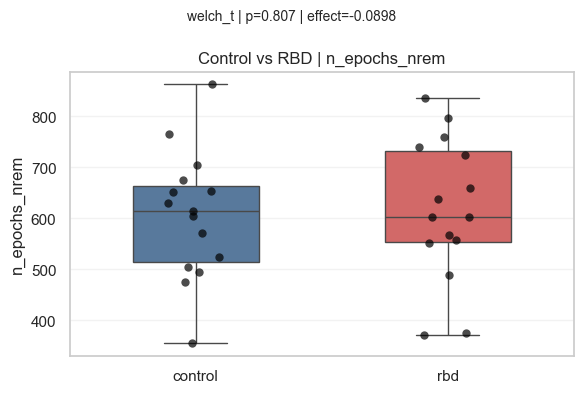

C:\Users\carlo\AppData\Local\Temp\ipykernel_11884\1060146072.py:298: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=group_col, y=metric, order=group_order, palette=palette, showfliers=False, width=0.5)


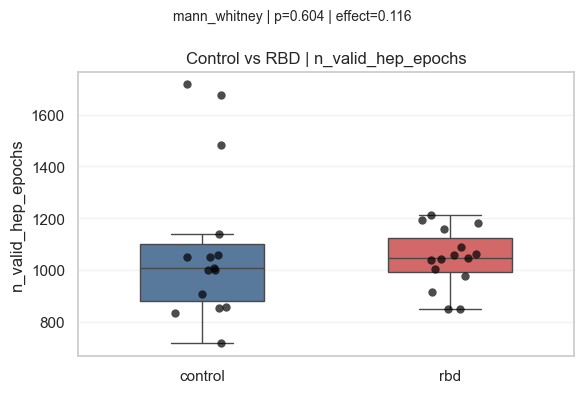

C:\Users\carlo\AppData\Local\Temp\ipykernel_11884\1060146072.py:298: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=group_col, y=metric, order=group_order, palette=palette, showfliers=False, width=0.5)


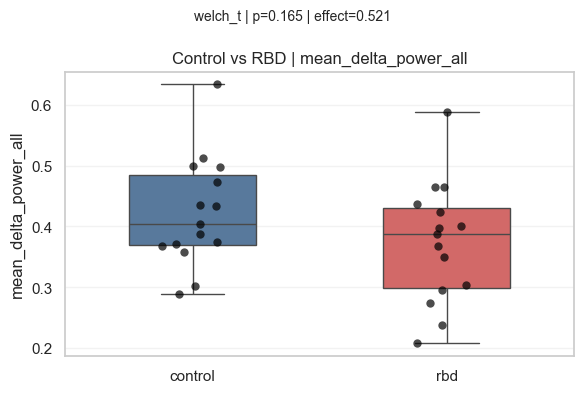

C:\Users\carlo\AppData\Local\Temp\ipykernel_11884\1060146072.py:298: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=group_col, y=metric, order=group_order, palette=palette, showfliers=False, width=0.5)


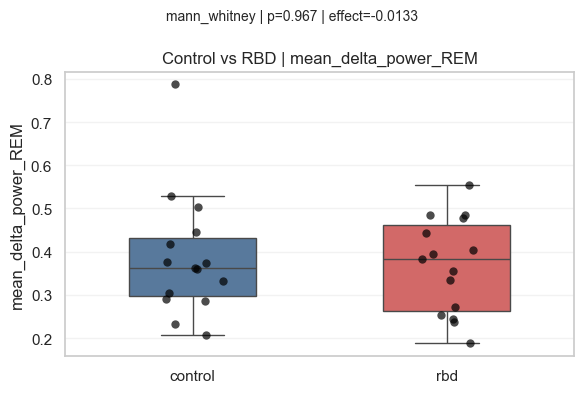

C:\Users\carlo\AppData\Local\Temp\ipykernel_11884\1060146072.py:298: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=group_col, y=metric, order=group_order, palette=palette, showfliers=False, width=0.5)


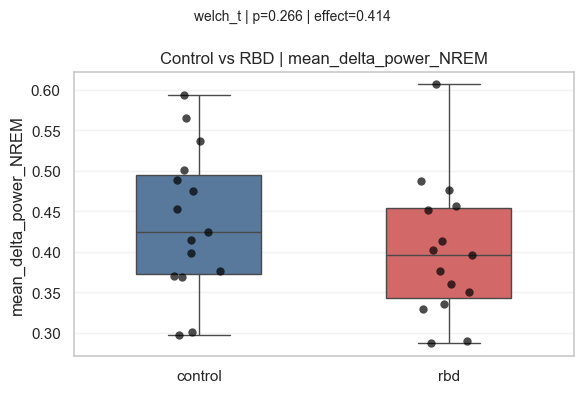

C:\Users\carlo\AppData\Local\Temp\ipykernel_11884\1060146072.py:298: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=group_col, y=metric, order=group_order, palette=palette, showfliers=False, width=0.5)


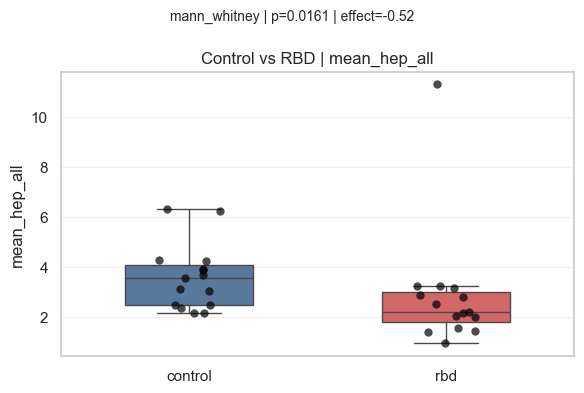

C:\Users\carlo\AppData\Local\Temp\ipykernel_11884\1060146072.py:298: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=group_col, y=metric, order=group_order, palette=palette, showfliers=False, width=0.5)


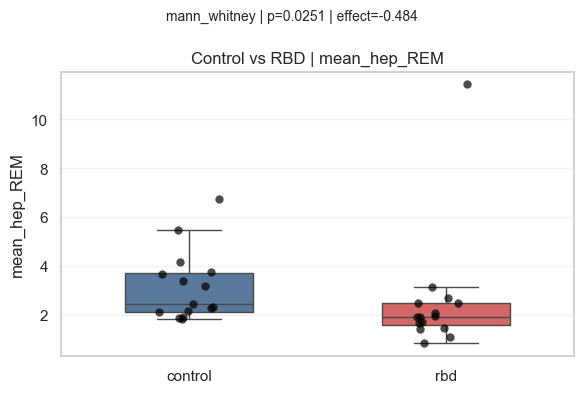

C:\Users\carlo\AppData\Local\Temp\ipykernel_11884\1060146072.py:298: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=group_col, y=metric, order=group_order, palette=palette, showfliers=False, width=0.5)


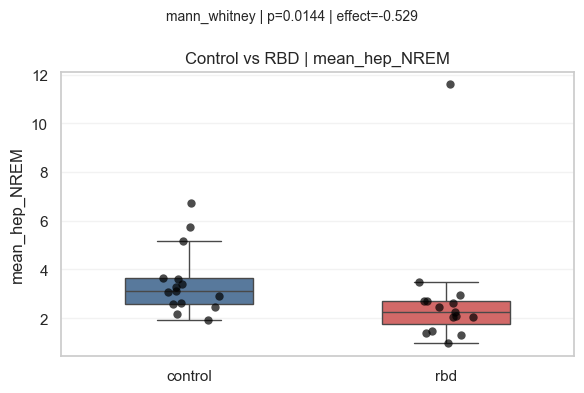

C:\Users\carlo\AppData\Local\Temp\ipykernel_11884\1060146072.py:298: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=group_col, y=metric, order=group_order, palette=palette, showfliers=False, width=0.5)


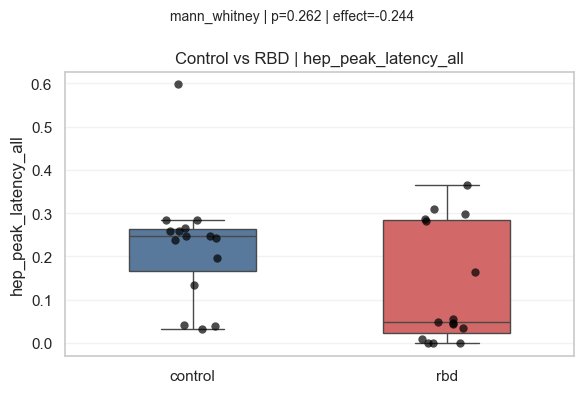

C:\Users\carlo\AppData\Local\Temp\ipykernel_11884\1060146072.py:298: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=group_col, y=metric, order=group_order, palette=palette, showfliers=False, width=0.5)


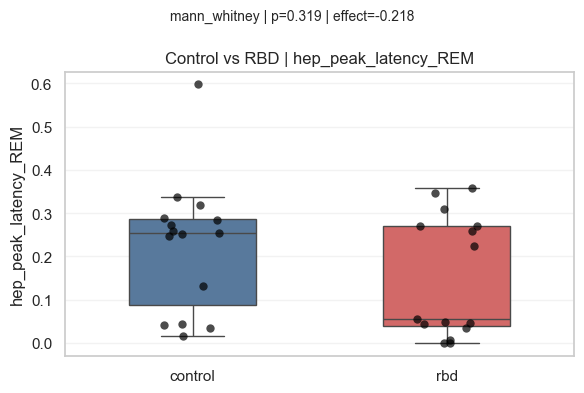

C:\Users\carlo\AppData\Local\Temp\ipykernel_11884\1060146072.py:298: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=group_col, y=metric, order=group_order, palette=palette, showfliers=False, width=0.5)


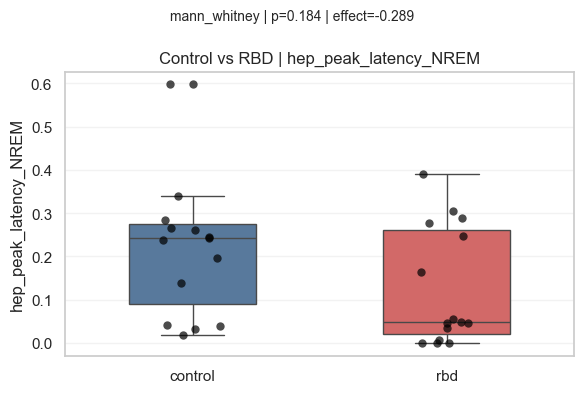

C:\Users\carlo\AppData\Local\Temp\ipykernel_11884\1060146072.py:298: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=group_col, y=metric, order=group_order, palette=palette, showfliers=False, width=0.5)


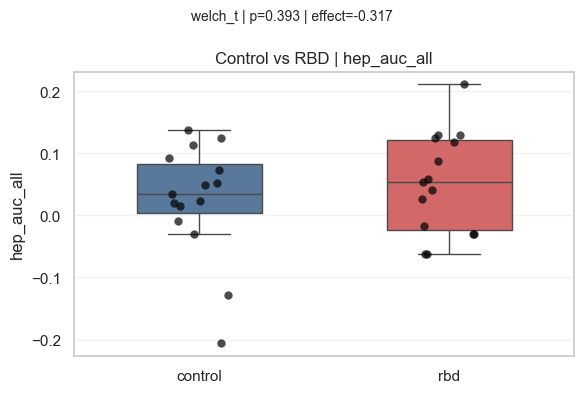

C:\Users\carlo\AppData\Local\Temp\ipykernel_11884\1060146072.py:298: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=group_col, y=metric, order=group_order, palette=palette, showfliers=False, width=0.5)


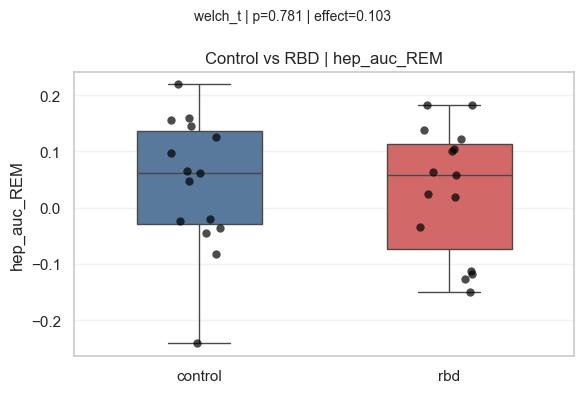

C:\Users\carlo\AppData\Local\Temp\ipykernel_11884\1060146072.py:298: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=group_col, y=metric, order=group_order, palette=palette, showfliers=False, width=0.5)


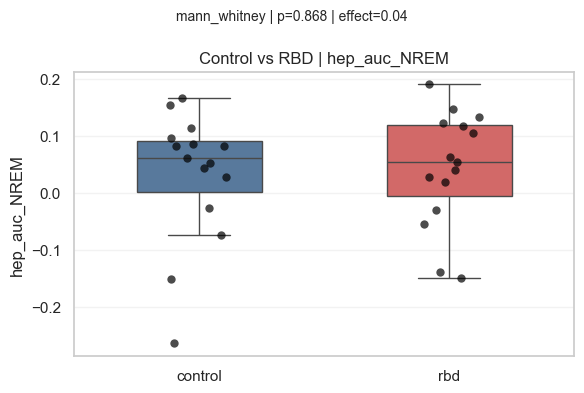

C:\Users\carlo\AppData\Local\Temp\ipykernel_11884\1060146072.py:298: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=group_col, y=metric, order=group_order, palette=palette, showfliers=False, width=0.5)


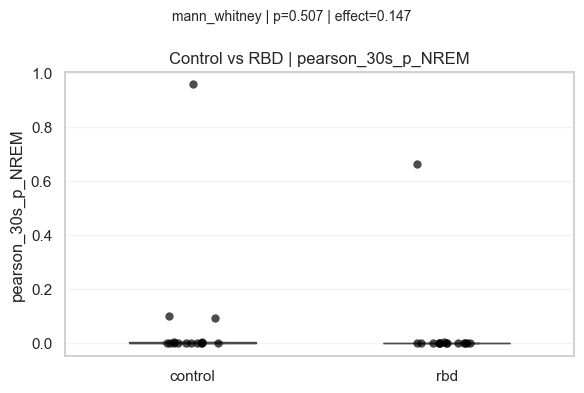

C:\Users\carlo\AppData\Local\Temp\ipykernel_11884\1060146072.py:298: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=group_col, y=metric, order=group_order, palette=palette, showfliers=False, width=0.5)


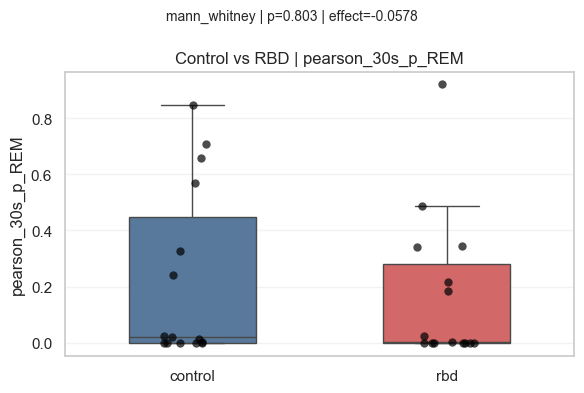

C:\Users\carlo\AppData\Local\Temp\ipykernel_11884\1060146072.py:298: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=group_col, y=metric, order=group_order, palette=palette, showfliers=False, width=0.5)


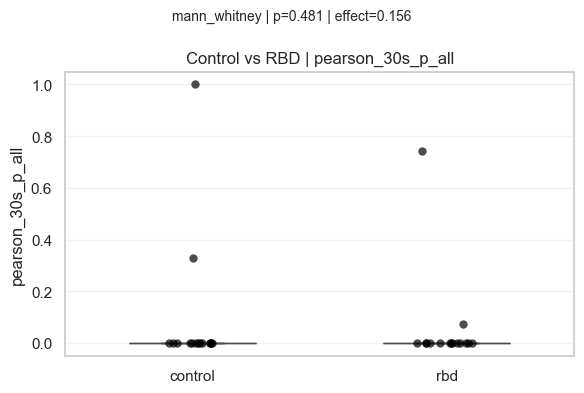

C:\Users\carlo\AppData\Local\Temp\ipykernel_11884\1060146072.py:298: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=group_col, y=metric, order=group_order, palette=palette, showfliers=False, width=0.5)


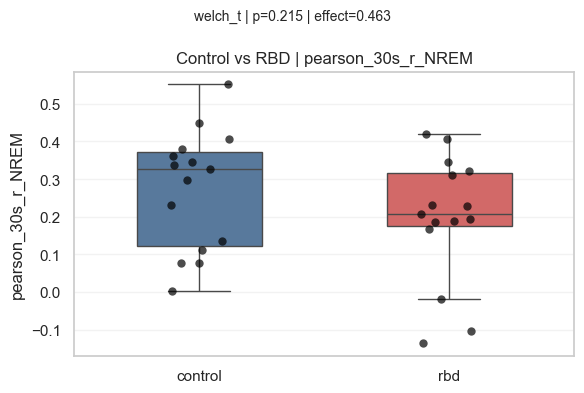

C:\Users\carlo\AppData\Local\Temp\ipykernel_11884\1060146072.py:298: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=group_col, y=metric, order=group_order, palette=palette, showfliers=False, width=0.5)


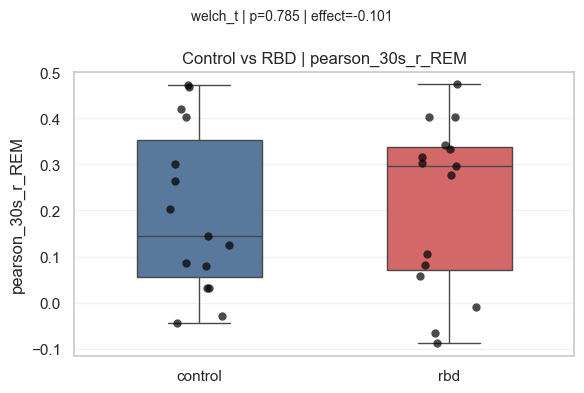

C:\Users\carlo\AppData\Local\Temp\ipykernel_11884\1060146072.py:298: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=group_col, y=metric, order=group_order, palette=palette, showfliers=False, width=0.5)


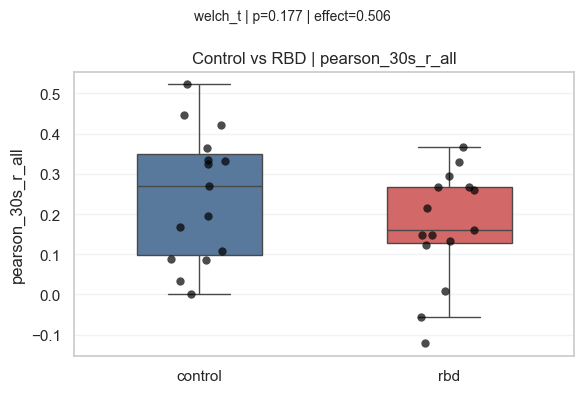

C:\Users\carlo\AppData\Local\Temp\ipykernel_11884\1060146072.py:298: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=group_col, y=metric, order=group_order, palette=palette, showfliers=False, width=0.5)


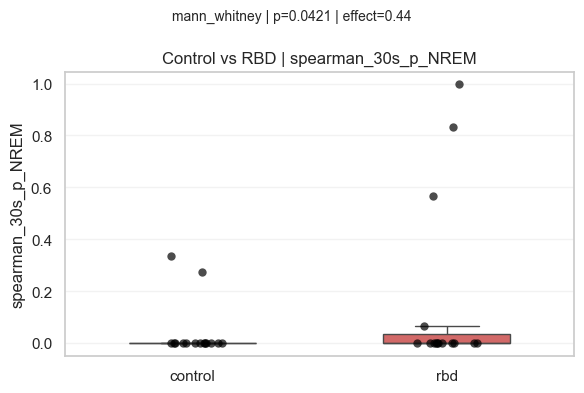

C:\Users\carlo\AppData\Local\Temp\ipykernel_11884\1060146072.py:298: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=group_col, y=metric, order=group_order, palette=palette, showfliers=False, width=0.5)


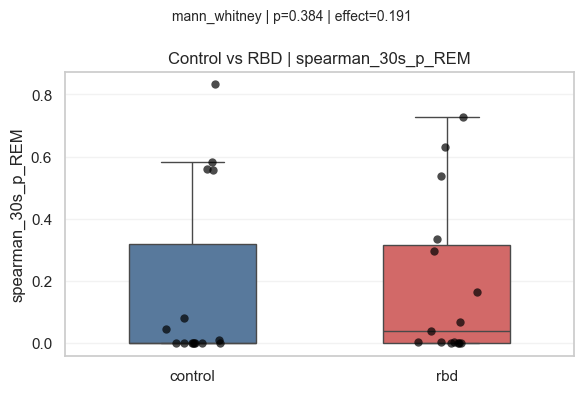

C:\Users\carlo\AppData\Local\Temp\ipykernel_11884\1060146072.py:298: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=group_col, y=metric, order=group_order, palette=palette, showfliers=False, width=0.5)


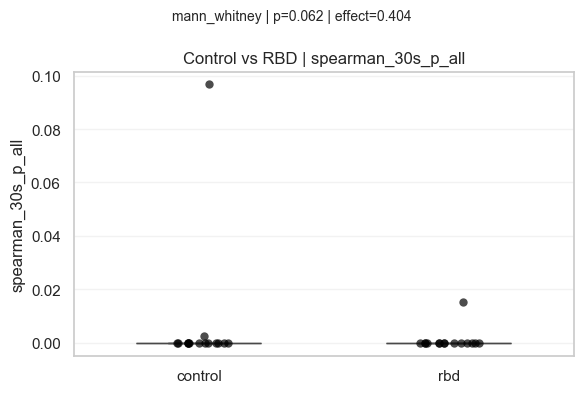

C:\Users\carlo\AppData\Local\Temp\ipykernel_11884\1060146072.py:298: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=group_col, y=metric, order=group_order, palette=palette, showfliers=False, width=0.5)


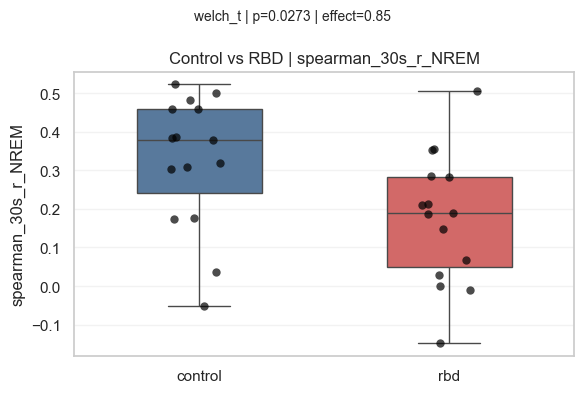

C:\Users\carlo\AppData\Local\Temp\ipykernel_11884\1060146072.py:298: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=group_col, y=metric, order=group_order, palette=palette, showfliers=False, width=0.5)


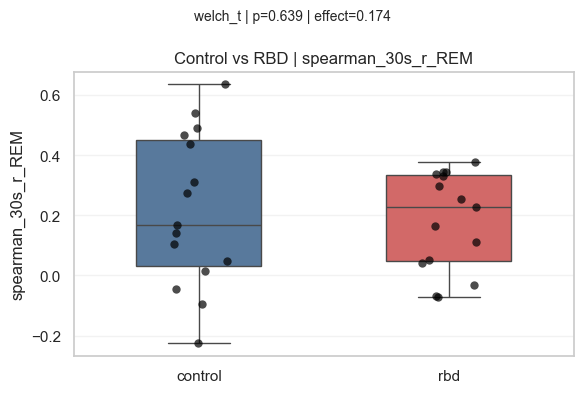

C:\Users\carlo\AppData\Local\Temp\ipykernel_11884\1060146072.py:298: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=group_col, y=metric, order=group_order, palette=palette, showfliers=False, width=0.5)


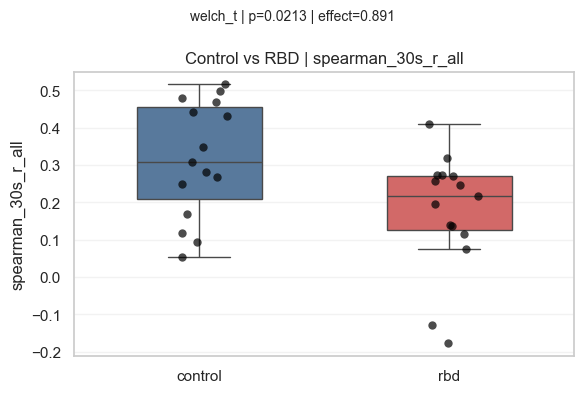

In [4]:
# Load data from HDF5 summaries into patient-level and epoch-level DataFrames
patient_df, stage_df, epoch_df = load_h5_summaries(hdf_dir)


print(f"Patients loaded: {len(patient_df)}")
print(patient_df["group"].value_counts(dropna=False))
display(patient_df[["patient_id", "group", "n_epochs_all", "n_valid_hep_epochs"]].sort_values(["group", "patient_id"]))

# Important: the group test is done on one summary value per patient, not per epoch.
patient_metrics = [
    col for col in patient_df.columns
    if col not in ["patient_id", "group"]
]

# Run group comparisons for all patient-level metrics and display results
stats_patient = run_stats_table(patient_df, patient_metrics) 
# split into control and RBD 
# compute descriptive stats 
# compute bootstrap confidence intervals 
# test normality to decide between t-test and Mann-Whitney U test~
# choose well's t-test if normal, Mann-Whitney U if not
# compute effect size
# apply BH correction later 
display(stats_patient.round(4))

# Save patient-level statistics to CSV
patient_csv = results_dir / "statistics_patient_level_results.csv"
stats_patient.drop(columns=["p_fdr_bh"], errors="ignore").to_csv(patient_csv, index=False)
print(f"Saved: {patient_csv}")

for metric in patient_metrics:
    plot_metric(patient_df, metric, title=f"Control vs RBD | {metric}")


In [5]:
print(stage_df.columns.tolist())

['patient_id', 'group', 'stage', 'delta', 'theta', 'alpha', 'beta', 'gamma', 'hr_mean_bpm', 'rmssd_ms', 'sdnn_ms', 'pnn50_pct', 'hfc', 'lfc', 'cpc_ratio', 'pearson_1s_r', 'spearman_1s_r', 'hep_30s', 'delta_30s']



Stage-level comparison for delta


,metric,n_control,n_rbd,mean_control,mean_control_ci_low,mean_control_ci_high,mean_rbd,mean_rbd_ci_low,mean_rbd_ci_high,mean_diff_control_minus_rbd,...,sd_rbd,test,statistic,p_value,effect_size,effect_name,shapiro_control_p,shapiro_rbd_p,stage,p_fdr_bh
0,delta,15,15,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,...,0.0,mann_whitney,155.0000,0.0815,-0.3778,rank_biserial,0.0000,0.0000,Wake,0.1019
1,delta,15,15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,mann_whitney,145.0000,0.1844,-0.2889,rank_biserial,0.0813,0.0001,N1,0.1844
2,delta,15,15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,mann_whitney,162.0000,0.0421,-0.4400,rank_biserial,0.0000,0.0001,N2,0.0702
3,delta,15,15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,mann_whitney,164.0000,0.0344,-0.4578,rank_biserial,0.0038,0.0685,N3,0.0702
4,delta,15,15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,welch_t,3.0917,0.0065,1.1289,cohen_d,0.0606,0.2363,REM,0.0325


Saved: c:\Users\carlo\OneDrive - Universidade de Lisboa\Documents\GitHub\heart-lung-brain-coupling-for-RBD\Notebooks\statistics_stage_level_delta.csv


C:\Users\carlo\AppData\Local\Temp\ipykernel_11884\1060146072.py:327: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=plot_df, x="stage", y=metric, hue="group", order=stage_order, hue_order=group_order, dodge=True, alpha=0.5, color="black", size=4, ax=ax)


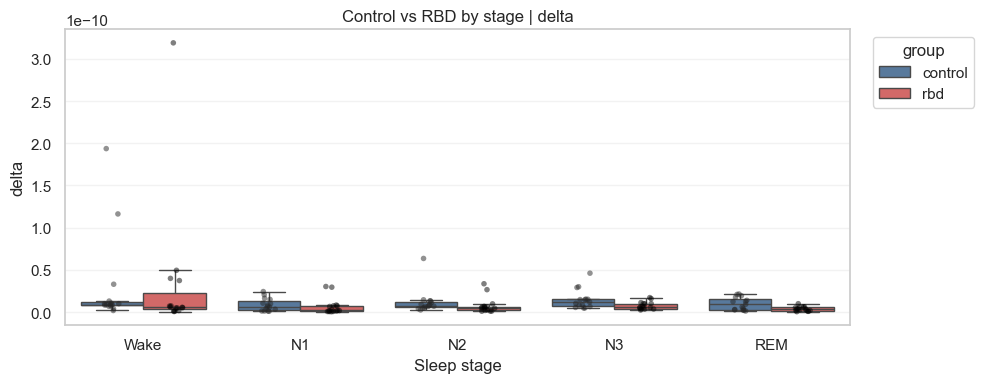


Stage-level comparison for theta


,metric,n_control,n_rbd,mean_control,mean_control_ci_low,mean_control_ci_high,mean_rbd,mean_rbd_ci_low,mean_rbd_ci_high,mean_diff_control_minus_rbd,...,sd_rbd,test,statistic,p_value,effect_size,effect_name,shapiro_control_p,shapiro_rbd_p,stage,p_fdr_bh
0,theta,15,15,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,...,0.0,mann_whitney,121.0000,0.7400,-0.0756,rank_biserial,0.0000,0.0000,Wake,0.7400
1,theta,15,15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,mann_whitney,141.0000,0.2455,-0.2533,rank_biserial,0.1308,0.0378,N1,0.3069
2,theta,15,15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,mann_whitney,141.0000,0.2455,-0.2533,rank_biserial,0.0003,0.3997,N2,0.3069
3,theta,15,15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,mann_whitney,142.0000,0.2290,-0.2622,rank_biserial,0.0927,0.0001,N3,0.3069
4,theta,15,15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,welch_t,2.5101,0.0209,0.9166,cohen_d,0.0505,0.0560,REM,0.1043


Saved: c:\Users\carlo\OneDrive - Universidade de Lisboa\Documents\GitHub\heart-lung-brain-coupling-for-RBD\Notebooks\statistics_stage_level_theta.csv


C:\Users\carlo\AppData\Local\Temp\ipykernel_11884\1060146072.py:327: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=plot_df, x="stage", y=metric, hue="group", order=stage_order, hue_order=group_order, dodge=True, alpha=0.5, color="black", size=4, ax=ax)


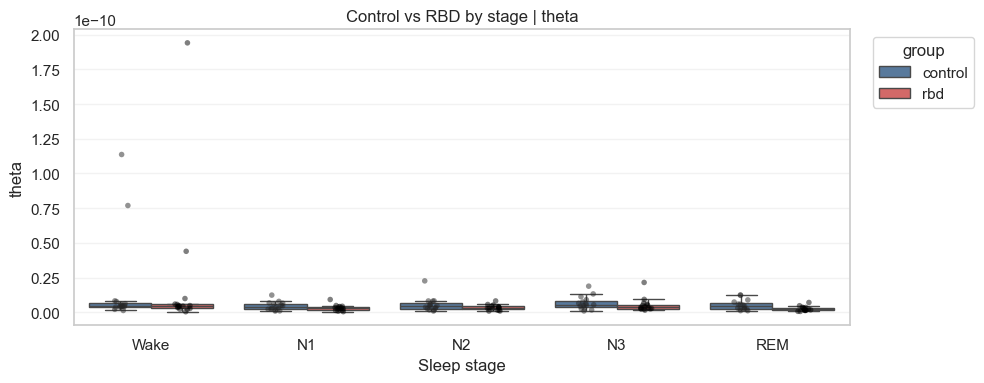


Stage-level comparison for alpha


,metric,n_control,n_rbd,mean_control,mean_control_ci_low,mean_control_ci_high,mean_rbd,mean_rbd_ci_low,mean_rbd_ci_high,mean_diff_control_minus_rbd,...,sd_rbd,test,statistic,p_value,effect_size,effect_name,shapiro_control_p,shapiro_rbd_p,stage,p_fdr_bh
0,alpha,15,15,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,...,0.0,mann_whitney,116.0,0.9010,-0.0311,rank_biserial,0.0000,0.0000,Wake,0.9010
1,alpha,15,15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,mann_whitney,143.0,0.2134,-0.2711,rank_biserial,0.3034,0.0138,N1,0.2863
2,alpha,15,15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,mann_whitney,150.0,0.1249,-0.3333,rank_biserial,0.0013,0.0418,N2,0.2863
3,alpha,15,15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,mann_whitney,142.0,0.2290,-0.2622,rank_biserial,0.0008,0.0000,N3,0.2863
4,alpha,15,15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,mann_whitney,164.0,0.0344,-0.4578,rank_biserial,0.0079,0.0018,REM,0.1720


Saved: c:\Users\carlo\OneDrive - Universidade de Lisboa\Documents\GitHub\heart-lung-brain-coupling-for-RBD\Notebooks\statistics_stage_level_alpha.csv


C:\Users\carlo\AppData\Local\Temp\ipykernel_11884\1060146072.py:327: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=plot_df, x="stage", y=metric, hue="group", order=stage_order, hue_order=group_order, dodge=True, alpha=0.5, color="black", size=4, ax=ax)


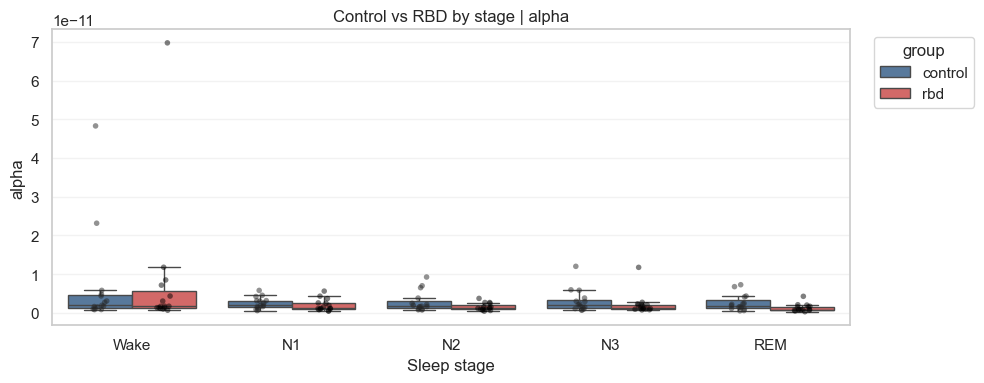


Stage-level comparison for beta


,metric,n_control,n_rbd,mean_control,mean_control_ci_low,mean_control_ci_high,mean_rbd,mean_rbd_ci_low,mean_rbd_ci_high,mean_diff_control_minus_rbd,...,sd_rbd,test,statistic,p_value,effect_size,effect_name,shapiro_control_p,shapiro_rbd_p,stage,p_fdr_bh
0,beta,15,15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,mann_whitney,135.0,0.3615,-0.2000,rank_biserial,0.0000,0.0000,Wake,0.3615
1,beta,15,15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,mann_whitney,163.0,0.0381,-0.4489,rank_biserial,0.0006,0.0000,N1,0.0476
2,beta,15,15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,mann_whitney,170.0,0.0181,-0.5111,rank_biserial,0.0000,0.0003,N2,0.0337
3,beta,15,15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,mann_whitney,169.0,0.0202,-0.5022,rank_biserial,0.0002,0.0000,N3,0.0337
4,beta,15,15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,mann_whitney,173.0,0.0128,-0.5378,rank_biserial,0.0255,0.0000,REM,0.0337


Saved: c:\Users\carlo\OneDrive - Universidade de Lisboa\Documents\GitHub\heart-lung-brain-coupling-for-RBD\Notebooks\statistics_stage_level_beta.csv


C:\Users\carlo\AppData\Local\Temp\ipykernel_11884\1060146072.py:327: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=plot_df, x="stage", y=metric, hue="group", order=stage_order, hue_order=group_order, dodge=True, alpha=0.5, color="black", size=4, ax=ax)


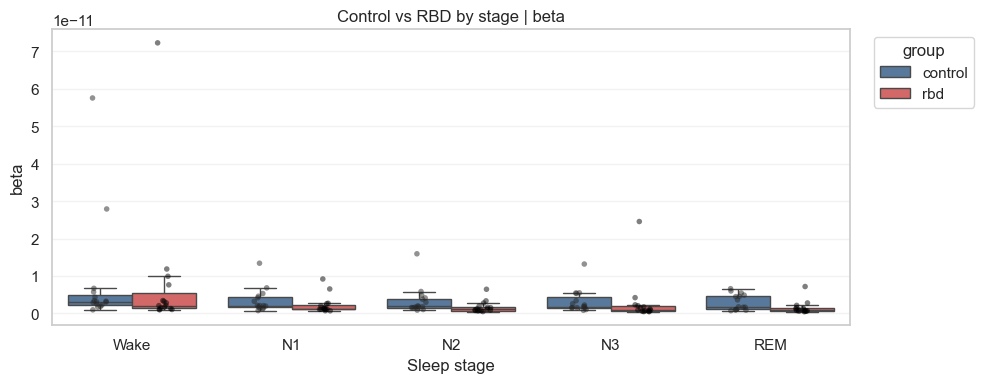


Stage-level comparison for gamma


,metric,n_control,n_rbd,mean_control,mean_control_ci_low,mean_control_ci_high,mean_rbd,mean_rbd_ci_low,mean_rbd_ci_high,mean_diff_control_minus_rbd,...,sd_rbd,test,statistic,p_value,effect_size,effect_name,shapiro_control_p,shapiro_rbd_p,stage,p_fdr_bh
0,gamma,15,15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,mann_whitney,133.0,0.4068,-0.1822,rank_biserial,0.0000,0.0,Wake,0.4068
1,gamma,15,15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,mann_whitney,158.0,0.0620,-0.4044,rank_biserial,0.0001,0.0,N1,0.1549
2,gamma,15,15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,mann_whitney,142.0,0.2290,-0.2622,rank_biserial,0.0034,0.0,N2,0.2863
3,gamma,15,15,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,...,0.0,mann_whitney,151.0,0.1150,-0.3422,rank_biserial,0.0005,0.0,N3,0.1916
4,gamma,15,15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,mann_whitney,159.0,0.0564,-0.4133,rank_biserial,0.0021,0.0,REM,0.1549


Saved: c:\Users\carlo\OneDrive - Universidade de Lisboa\Documents\GitHub\heart-lung-brain-coupling-for-RBD\Notebooks\statistics_stage_level_gamma.csv


C:\Users\carlo\AppData\Local\Temp\ipykernel_11884\1060146072.py:327: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=plot_df, x="stage", y=metric, hue="group", order=stage_order, hue_order=group_order, dodge=True, alpha=0.5, color="black", size=4, ax=ax)


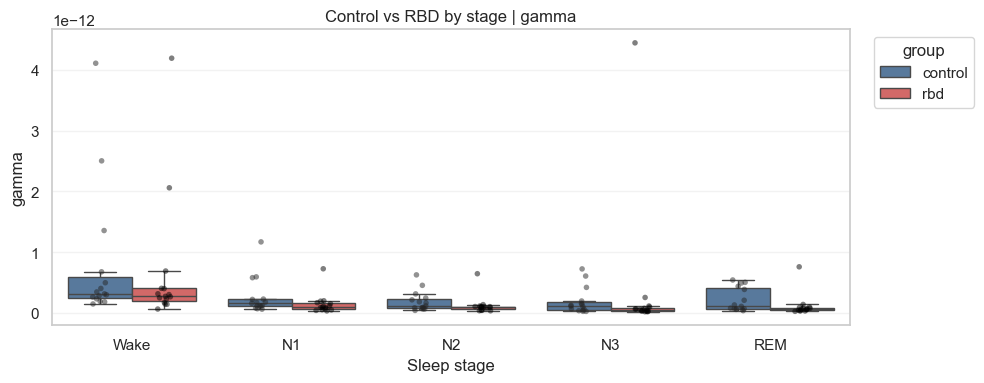


Stage-level comparison for hr_mean_bpm


,metric,n_control,n_rbd,mean_control,mean_control_ci_low,mean_control_ci_high,mean_rbd,mean_rbd_ci_low,mean_rbd_ci_high,mean_diff_control_minus_rbd,...,sd_rbd,test,statistic,p_value,effect_size,effect_name,shapiro_control_p,shapiro_rbd_p,stage,p_fdr_bh
0,hr_mean_bpm,15,15,74.2157,69.7005,78.9729,63.8082,57.0811,69.8223,10.4075,...,12.9095,welch_t,2.5127,0.0186,0.9175,cohen_d,0.8038,0.0901,Wake,0.0418
1,hr_mean_bpm,15,15,72.1216,67.4661,77.0660,62.6048,55.4300,68.8152,9.5168,...,13.4514,welch_t,2.2132,0.0360,0.8081,cohen_d,0.2795,0.0789,N1,0.0450
2,hr_mean_bpm,15,15,69.7206,65.2027,74.0191,61.1320,54.4154,67.3809,8.5887,...,12.9883,welch_t,2.1061,0.0454,0.7691,cohen_d,0.6706,0.1585,N2,0.0454
3,hr_mean_bpm,15,15,72.2601,66.9936,77.4540,60.9356,53.3455,67.5176,11.3245,...,14.1559,welch_t,2.4726,0.0203,0.9029,cohen_d,0.3875,0.0704,N3,0.0418
4,hr_mean_bpm,15,15,69.4040,65.4388,73.2584,60.4237,53.2525,66.7898,8.9803,...,13.5533,mann_whitney,167.0000,0.0251,-0.4844,rank_biserial,0.2691,0.0484,REM,0.0418


Saved: c:\Users\carlo\OneDrive - Universidade de Lisboa\Documents\GitHub\heart-lung-brain-coupling-for-RBD\Notebooks\statistics_stage_level_hr_mean_bpm.csv


C:\Users\carlo\AppData\Local\Temp\ipykernel_11884\1060146072.py:327: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=plot_df, x="stage", y=metric, hue="group", order=stage_order, hue_order=group_order, dodge=True, alpha=0.5, color="black", size=4, ax=ax)


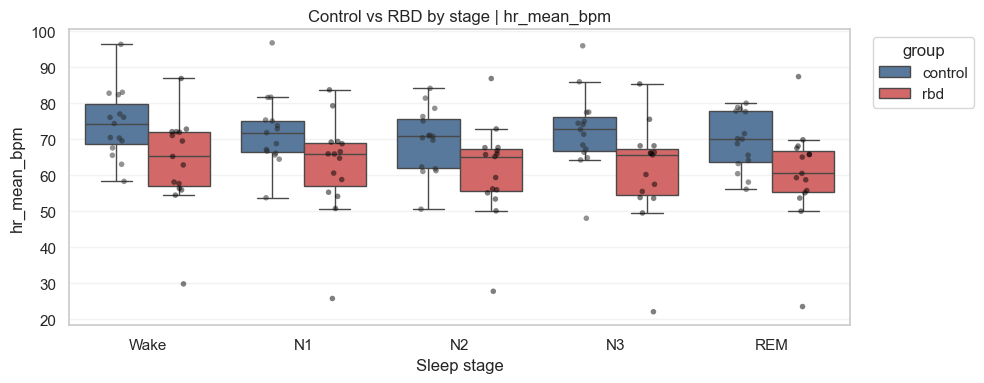


Stage-level comparison for rmssd_ms


,metric,n_control,n_rbd,mean_control,mean_control_ci_low,mean_control_ci_high,mean_rbd,mean_rbd_ci_low,mean_rbd_ci_high,mean_diff_control_minus_rbd,...,sd_rbd,test,statistic,p_value,effect_size,effect_name,shapiro_control_p,shapiro_rbd_p,stage,p_fdr_bh
0,rmssd_ms,15,15,101.3827,70.6703,138.8261,302.0923,77.4786,687.7610,-200.7096,...,694.3903,mann_whitney,111.0,0.9669,0.0133,rank_biserial,0.0311,0.0,Wake,0.9669
1,rmssd_ms,15,15,83.4944,55.1011,116.6553,317.4317,49.1405,831.9320,-233.9373,...,979.5628,mann_whitney,120.0,0.7716,-0.0667,rank_biserial,0.0276,0.0,N1,0.9669
2,rmssd_ms,15,15,95.7091,57.5736,143.5200,291.9167,47.9922,753.3617,-196.2076,...,872.6209,mann_whitney,123.0,0.6783,-0.0933,rank_biserial,0.0017,0.0,N2,0.9669
3,rmssd_ms,15,15,70.9781,47.9867,95.2147,333.6289,44.9565,887.0472,-262.6508,...,1053.5686,mann_whitney,115.0,0.9339,-0.0222,rank_biserial,0.1614,0.0,N3,0.9669
4,rmssd_ms,15,15,96.7188,58.2048,146.1510,320.7911,48.7319,832.8229,-224.0722,...,962.8928,mann_whitney,119.0,0.8035,-0.0578,rank_biserial,0.0019,0.0,REM,0.9669


Saved: c:\Users\carlo\OneDrive - Universidade de Lisboa\Documents\GitHub\heart-lung-brain-coupling-for-RBD\Notebooks\statistics_stage_level_rmssd_ms.csv


C:\Users\carlo\AppData\Local\Temp\ipykernel_11884\1060146072.py:327: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=plot_df, x="stage", y=metric, hue="group", order=stage_order, hue_order=group_order, dodge=True, alpha=0.5, color="black", size=4, ax=ax)


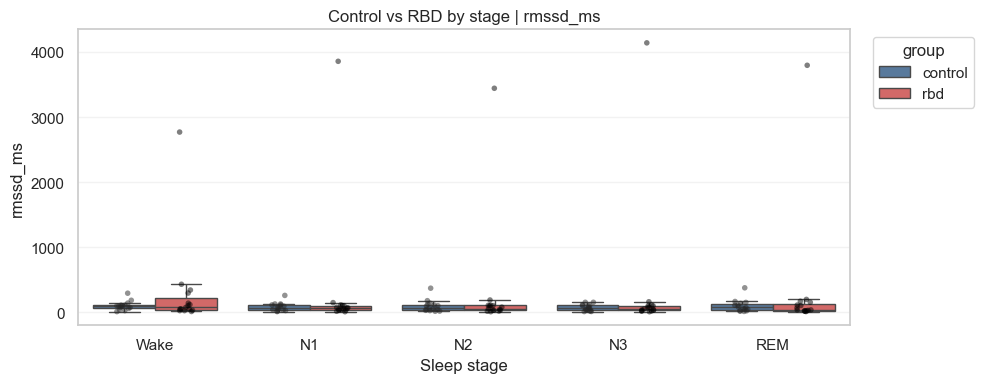


Stage-level comparison for sdnn_ms


,metric,n_control,n_rbd,mean_control,mean_control_ci_low,mean_control_ci_high,mean_rbd,mean_rbd_ci_low,mean_rbd_ci_high,mean_diff_control_minus_rbd,...,sd_rbd,test,statistic,p_value,effect_size,effect_name,shapiro_control_p,shapiro_rbd_p,stage,p_fdr_bh
0,sdnn_ms,15,15,85.9442,62.1971,115.7998,237.6141,65.5103,530.3514,-151.6699,...,526.5963,mann_whitney,118.0,0.8357,-0.0489,rank_biserial,0.0130,0.0,Wake,0.8357
1,sdnn_ms,15,15,71.4223,51.7552,94.6447,236.9019,43.9235,605.8120,-165.4796,...,700.3758,mann_whitney,131.0,0.4553,-0.1644,rank_biserial,0.0170,0.0,N1,0.8357
2,sdnn_ms,15,15,78.8343,53.2533,110.2259,226.2868,44.3497,571.0324,-147.4526,...,651.3072,mann_whitney,129.0,0.5069,-0.1467,rank_biserial,0.0056,0.0,N2,0.8357
3,sdnn_ms,15,15,58.6532,42.9133,75.1410,251.7802,39.6917,658.0377,-193.1271,...,771.3836,mann_whitney,120.0,0.7716,-0.0667,rank_biserial,0.2672,0.0,N3,0.8357
4,sdnn_ms,15,15,84.1719,52.7191,127.3803,250.6842,43.8267,640.1627,-166.5123,...,731.3396,mann_whitney,126.0,0.5897,-0.1200,rank_biserial,0.0003,0.0,REM,0.8357


Saved: c:\Users\carlo\OneDrive - Universidade de Lisboa\Documents\GitHub\heart-lung-brain-coupling-for-RBD\Notebooks\statistics_stage_level_sdnn_ms.csv


C:\Users\carlo\AppData\Local\Temp\ipykernel_11884\1060146072.py:327: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=plot_df, x="stage", y=metric, hue="group", order=stage_order, hue_order=group_order, dodge=True, alpha=0.5, color="black", size=4, ax=ax)


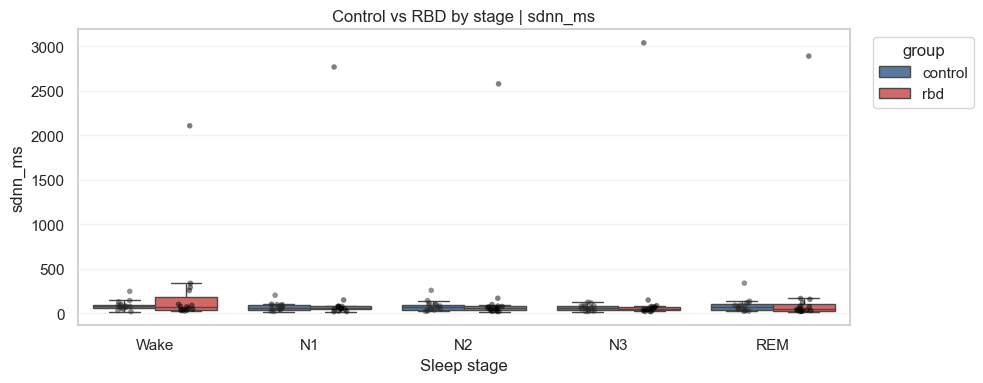


Stage-level comparison for pnn50_pct


,metric,n_control,n_rbd,mean_control,mean_control_ci_low,mean_control_ci_high,mean_rbd,mean_rbd_ci_low,mean_rbd_ci_high,mean_diff_control_minus_rbd,...,sd_rbd,test,statistic,p_value,effect_size,effect_name,shapiro_control_p,shapiro_rbd_p,stage,p_fdr_bh
0,pnn50_pct,15,15,30.8687,22.2611,38.9458,28.6966,17.3977,40.4536,2.1720,...,23.5632,welch_t,0.2882,0.7755,0.1052,cohen_d,0.4904,0.2294,Wake,0.7755
1,pnn50_pct,15,15,29.0972,19.9932,38.1039,24.6022,12.7201,37.8335,4.4949,...,25.9016,mann_whitney,133.0000,0.4068,-0.1822,rank_biserial,0.6078,0.0090,N1,0.7755
2,pnn50_pct,15,15,28.1206,18.4346,37.8837,24.0544,12.0474,37.4294,4.0662,...,25.8468,mann_whitney,130.0000,0.4807,-0.1556,rank_biserial,0.3264,0.0041,N2,0.7755
3,pnn50_pct,15,15,29.3708,17.7216,41.3563,22.8527,11.5380,35.4391,6.5181,...,24.5975,mann_whitney,131.0000,0.4553,-0.1644,rank_biserial,0.0705,0.0064,N3,0.7755
4,pnn50_pct,15,15,26.3386,16.8443,35.9276,24.4077,12.2298,37.6305,1.9309,...,26.0963,mann_whitney,123.0000,0.6783,-0.0933,rank_biserial,0.3434,0.0070,REM,0.7755


Saved: c:\Users\carlo\OneDrive - Universidade de Lisboa\Documents\GitHub\heart-lung-brain-coupling-for-RBD\Notebooks\statistics_stage_level_pnn50_pct.csv


C:\Users\carlo\AppData\Local\Temp\ipykernel_11884\1060146072.py:327: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=plot_df, x="stage", y=metric, hue="group", order=stage_order, hue_order=group_order, dodge=True, alpha=0.5, color="black", size=4, ax=ax)


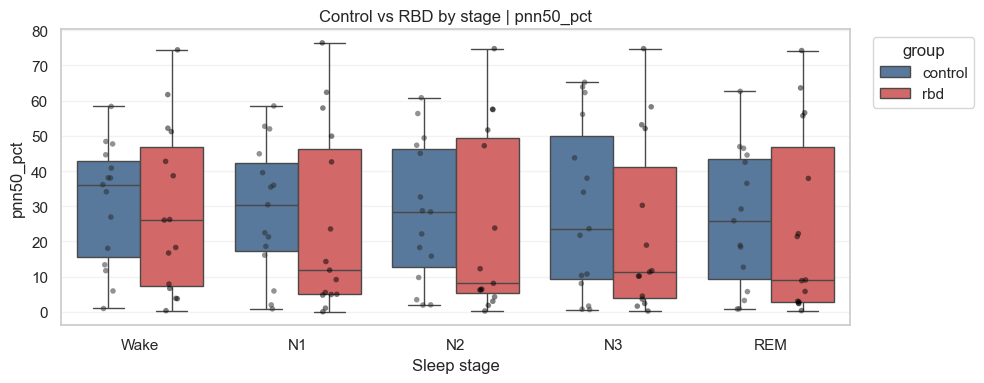


Stage-level comparison for hfc


,metric,n_control,n_rbd,mean_control,mean_control_ci_low,mean_control_ci_high,mean_rbd,mean_rbd_ci_low,mean_rbd_ci_high,mean_diff_control_minus_rbd,...,sd_rbd,test,statistic,p_value,effect_size,effect_name,shapiro_control_p,shapiro_rbd_p,stage,p_fdr_bh
0,hfc,15,15,237859.1731,143110.4276,344284.1547,425200.4986,152582.9467,808061.4322,-187341.3255,...,682515.0388,mann_whitney,112.0,1.0000,0.0044,rank_biserial,0.0410,0.0,Wake,1.0000
1,hfc,15,15,247434.2190,97205.9291,449013.7028,327919.3298,64514.3349,768612.4049,-80485.1108,...,763324.2196,mann_whitney,122.0,0.7089,-0.0844,rank_biserial,0.0001,0.0,N1,0.8862
2,hfc,15,15,164138.5730,91404.6614,248952.0797,277776.9359,63785.3225,627881.0917,-113638.3629,...,609800.9429,mann_whitney,127.0,0.5614,-0.1289,rank_biserial,0.0101,0.0,N2,0.8862
3,hfc,15,15,138018.5942,74976.3853,216763.4016,295820.9144,56874.9022,686418.7260,-157802.3202,...,682219.1862,mann_whitney,128.0,0.5338,-0.1378,rank_biserial,0.0022,0.0,N3,0.8862
4,hfc,15,15,157925.0601,76973.2285,254958.0496,327696.8035,86465.5859,701578.3874,-169771.7433,...,652624.8864,mann_whitney,99.0,0.5897,0.1200,rank_biserial,0.0021,0.0,REM,0.8862


Saved: c:\Users\carlo\OneDrive - Universidade de Lisboa\Documents\GitHub\heart-lung-brain-coupling-for-RBD\Notebooks\statistics_stage_level_hfc.csv


C:\Users\carlo\AppData\Local\Temp\ipykernel_11884\1060146072.py:327: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=plot_df, x="stage", y=metric, hue="group", order=stage_order, hue_order=group_order, dodge=True, alpha=0.5, color="black", size=4, ax=ax)


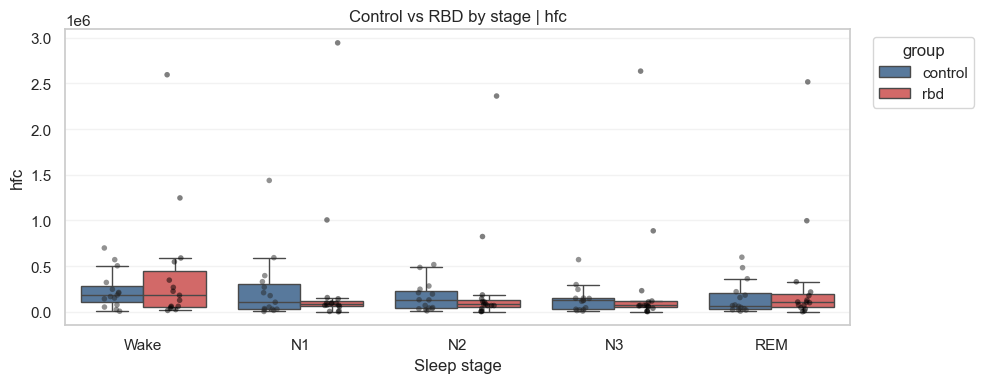


Stage-level comparison for lfc


,metric,n_control,n_rbd,mean_control,mean_control_ci_low,mean_control_ci_high,mean_rbd,mean_rbd_ci_low,mean_rbd_ci_high,mean_diff_control_minus_rbd,...,sd_rbd,test,statistic,p_value,effect_size,effect_name,shapiro_control_p,shapiro_rbd_p,stage,p_fdr_bh
0,lfc,15,15,64206.2173,33701.3499,102005.0472,144398.7395,35872.8569,309114.1857,-80192.5222,...,291967.4529,mann_whitney,124.0,0.6482,-0.1022,rank_biserial,0.0009,0.0,Wake,0.740
1,lfc,15,15,52616.9805,21314.9076,90779.4334,116580.1636,8491.7489,314118.0357,-63963.1830,...,356935.9425,mann_whitney,139.0,0.2808,-0.2356,rank_biserial,0.0006,0.0,N1,0.678
2,lfc,15,15,37428.2950,21892.0668,55452.0654,107644.8336,11606.9261,283585.2348,-70216.5386,...,323373.7494,mann_whitney,140.0,0.2628,-0.2444,rank_biserial,0.0330,0.0,N2,0.678
3,lfc,15,15,28092.2298,14530.9632,45289.3261,99452.6186,9038.2477,262683.6917,-71360.3888,...,298926.0176,mann_whitney,133.0,0.4068,-0.1822,rank_biserial,0.0019,0.0,N3,0.678
4,lfc,15,15,47954.5061,19456.6908,86368.7986,111471.2771,14861.7440,285654.8861,-63516.7710,...,321609.1057,mann_whitney,121.0,0.7400,-0.0756,rank_biserial,0.0001,0.0,REM,0.740


Saved: c:\Users\carlo\OneDrive - Universidade de Lisboa\Documents\GitHub\heart-lung-brain-coupling-for-RBD\Notebooks\statistics_stage_level_lfc.csv


C:\Users\carlo\AppData\Local\Temp\ipykernel_11884\1060146072.py:327: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=plot_df, x="stage", y=metric, hue="group", order=stage_order, hue_order=group_order, dodge=True, alpha=0.5, color="black", size=4, ax=ax)


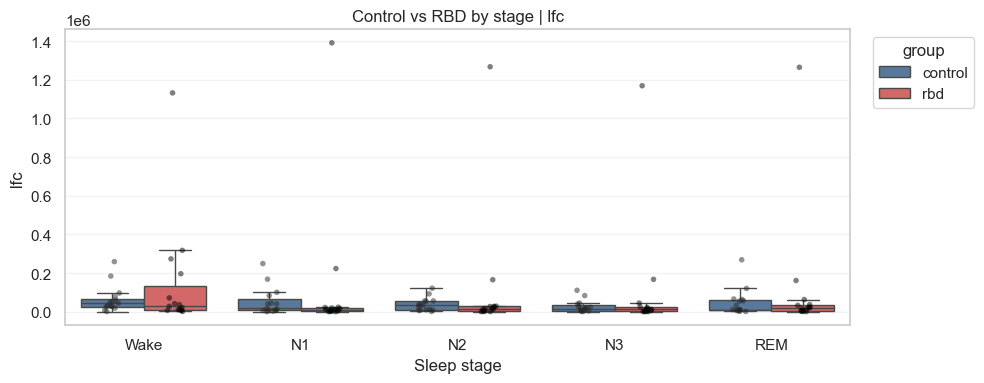


Stage-level comparison for cpc_ratio


,metric,n_control,n_rbd,mean_control,mean_control_ci_low,mean_control_ci_high,mean_rbd,mean_rbd_ci_low,mean_rbd_ci_high,mean_diff_control_minus_rbd,...,sd_rbd,test,statistic,p_value,effect_size,effect_name,shapiro_control_p,shapiro_rbd_p,stage,p_fdr_bh
0,cpc_ratio,15,15,0.2888,0.2043,0.3908,0.2333,0.1633,0.3196,0.0556,...,0.1657,mann_whitney,129.0,0.5069,-0.1467,rank_biserial,0.0067,0.0052,Wake,0.5614
1,cpc_ratio,15,15,0.2588,0.1874,0.3532,0.2530,0.1307,0.4118,0.0057,...,0.2922,mann_whitney,152.0,0.1057,-0.3511,rank_biserial,0.0011,0.0003,N1,0.2641
2,cpc_ratio,15,15,0.2697,0.2145,0.3378,0.2326,0.1459,0.3431,0.0371,...,0.2062,mann_whitney,147.0,0.1585,-0.3067,rank_biserial,0.0035,0.0005,N2,0.2641
3,cpc_ratio,15,15,0.2618,0.1733,0.3681,0.2060,0.1269,0.3090,0.0558,...,0.1897,mann_whitney,127.0,0.5614,-0.1289,rank_biserial,0.0006,0.0004,N3,0.5614
4,cpc_ratio,15,15,0.3277,0.2512,0.4130,0.2380,0.1583,0.3372,0.0897,...,0.1863,mann_whitney,159.0,0.0564,-0.4133,rank_biserial,0.0873,0.0017,REM,0.2641


Saved: c:\Users\carlo\OneDrive - Universidade de Lisboa\Documents\GitHub\heart-lung-brain-coupling-for-RBD\Notebooks\statistics_stage_level_cpc_ratio.csv


C:\Users\carlo\AppData\Local\Temp\ipykernel_11884\1060146072.py:327: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=plot_df, x="stage", y=metric, hue="group", order=stage_order, hue_order=group_order, dodge=True, alpha=0.5, color="black", size=4, ax=ax)


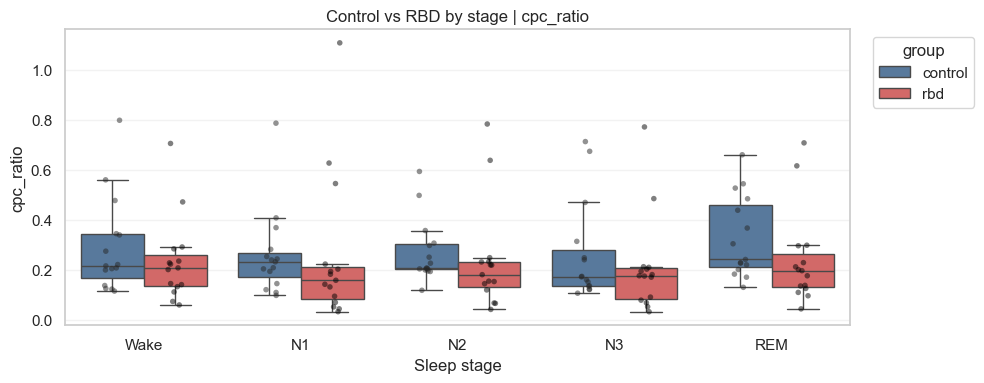


Stage-level comparison for pearson_1s_r


,metric,n_control,n_rbd,mean_control,mean_control_ci_low,mean_control_ci_high,mean_rbd,mean_rbd_ci_low,mean_rbd_ci_high,mean_diff_control_minus_rbd,...,sd_rbd,test,statistic,p_value,effect_size,effect_name,shapiro_control_p,shapiro_rbd_p,stage,p_fdr_bh
0,pearson_1s_r,15,15,0.1132,0.0575,0.1667,0.1558,0.1001,0.2122,-0.0426,...,0.1136,welch_t,-1.0326,0.3106,-0.3770,cohen_d,0.1847,0.9147,Wake,0.3883
1,pearson_1s_r,15,14,0.0461,-0.0365,0.1285,0.1184,0.0554,0.1924,-0.0723,...,0.1356,welch_t,-1.2642,0.2172,-0.4660,cohen_d,0.4741,0.1385,N1,0.3620
2,pearson_1s_r,15,15,0.1519,0.1100,0.1916,0.1839,0.1400,0.2352,-0.0320,...,0.0967,mann_whitney,112.0000,1.0000,0.0044,rank_biserial,0.4057,0.0030,N2,1.0000
3,pearson_1s_r,15,15,0.1673,0.1154,0.2099,0.2190,0.1729,0.2711,-0.0516,...,0.1010,mann_whitney,82.0000,0.2134,0.2711,rank_biserial,0.0040,0.0238,N3,0.3620
4,pearson_1s_r,15,15,0.1233,0.0729,0.1723,0.1789,0.1224,0.2386,-0.0557,...,0.1172,welch_t,-1.3899,0.1757,-0.5075,cohen_d,0.8663,0.9749,REM,0.3620


Saved: c:\Users\carlo\OneDrive - Universidade de Lisboa\Documents\GitHub\heart-lung-brain-coupling-for-RBD\Notebooks\statistics_stage_level_pearson_1s_r.csv


C:\Users\carlo\AppData\Local\Temp\ipykernel_11884\1060146072.py:327: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=plot_df, x="stage", y=metric, hue="group", order=stage_order, hue_order=group_order, dodge=True, alpha=0.5, color="black", size=4, ax=ax)


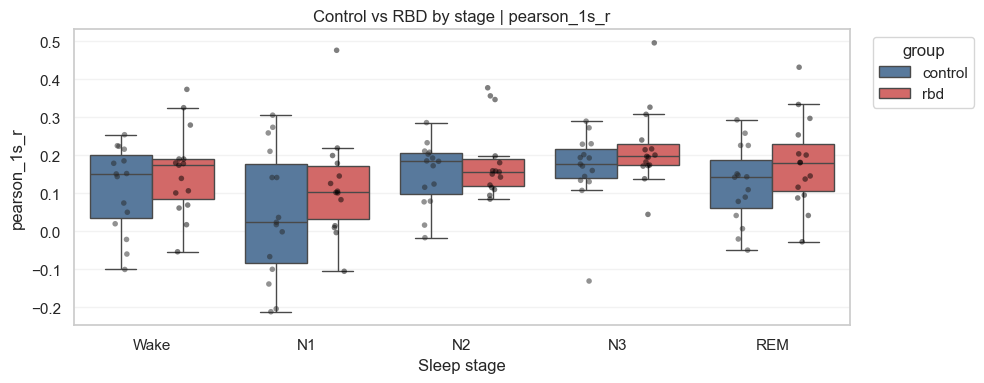


Stage-level comparison for spearman_1s_r


,metric,n_control,n_rbd,mean_control,mean_control_ci_low,mean_control_ci_high,mean_rbd,mean_rbd_ci_low,mean_rbd_ci_high,mean_diff_control_minus_rbd,...,sd_rbd,test,statistic,p_value,effect_size,effect_name,shapiro_control_p,shapiro_rbd_p,stage,p_fdr_bh
0,spearman_1s_r,15,15,0.0806,0.0334,0.1277,0.0988,0.0417,0.1569,-0.0182,...,0.1164,welch_t,-0.4678,0.6437,-0.1708,cohen_d,0.6481,0.8715,Wake,0.8035
1,spearman_1s_r,15,14,0.0308,-0.0482,0.1073,0.0625,0.0039,0.1242,-0.0317,...,0.1190,welch_t,-0.6069,0.5493,-0.2232,cohen_d,0.6032,0.8274,N1,0.8035
2,spearman_1s_r,15,15,0.1094,0.0654,0.1509,0.1293,0.0844,0.1809,-0.0199,...,0.0986,mann_whitney,119.0000,0.8035,-0.0578,rank_biserial,0.2068,0.0051,N2,0.8035
3,spearman_1s_r,15,15,0.1435,0.1048,0.1790,0.1900,0.1396,0.2500,-0.0466,...,0.1131,mann_whitney,93.0000,0.4306,0.1733,rank_biserial,0.4960,0.0057,N3,0.8035
4,spearman_1s_r,15,15,0.0962,0.0461,0.1441,0.1240,0.0671,0.1851,-0.0277,...,0.1195,welch_t,-0.6881,0.4972,-0.2512,cohen_d,0.4513,0.6851,REM,0.8035


Saved: c:\Users\carlo\OneDrive - Universidade de Lisboa\Documents\GitHub\heart-lung-brain-coupling-for-RBD\Notebooks\statistics_stage_level_spearman_1s_r.csv


C:\Users\carlo\AppData\Local\Temp\ipykernel_11884\1060146072.py:327: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=plot_df, x="stage", y=metric, hue="group", order=stage_order, hue_order=group_order, dodge=True, alpha=0.5, color="black", size=4, ax=ax)


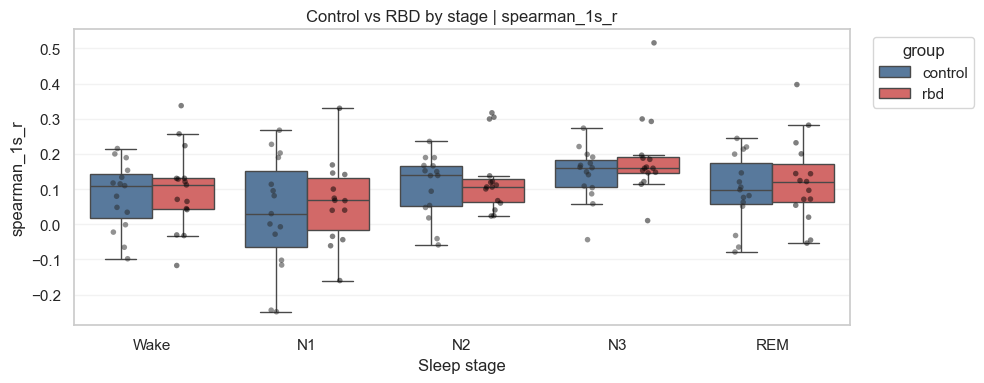


Stage-level comparison for hep_30s


,metric,n_control,n_rbd,mean_control,mean_control_ci_low,mean_control_ci_high,mean_rbd,mean_rbd_ci_low,mean_rbd_ci_high,mean_diff_control_minus_rbd,...,sd_rbd,test,statistic,p_value,effect_size,effect_name,shapiro_control_p,shapiro_rbd_p,stage,p_fdr_bh
0,hep_30s,15,15,4.0602,3.1791,5.0722,3.0402,2.2018,4.3190,1.0200,...,2.2380,mann_whitney,161.0,0.0465,-0.4311,rank_biserial,0.0634,0.0000,Wake,0.0620
1,hep_30s,15,15,3.5680,2.7143,4.6061,2.9867,1.8558,4.5001,0.5813,...,2.7058,mann_whitney,160.0,0.0512,-0.4222,rank_biserial,0.0030,0.0001,N1,0.0620
2,hep_30s,15,15,3.2837,2.6004,4.1178,2.7013,1.8466,4.0799,0.5823,...,2.4731,mann_whitney,158.0,0.0620,-0.4044,rank_biserial,0.0023,0.0000,N2,0.0620
3,hep_30s,15,15,3.8396,3.1791,4.5284,3.0078,2.0286,4.5979,0.8317,...,2.8497,mann_whitney,176.0,0.0090,-0.5644,rank_biserial,0.5460,0.0000,N3,0.0449
4,hep_30s,15,15,3.1398,2.4896,3.8874,2.5382,1.6811,3.9392,0.6016,...,2.5351,mann_whitney,167.0,0.0251,-0.4844,rank_biserial,0.0134,0.0000,REM,0.0620


Saved: c:\Users\carlo\OneDrive - Universidade de Lisboa\Documents\GitHub\heart-lung-brain-coupling-for-RBD\Notebooks\statistics_stage_level_hep_30s.csv


C:\Users\carlo\AppData\Local\Temp\ipykernel_11884\1060146072.py:327: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=plot_df, x="stage", y=metric, hue="group", order=stage_order, hue_order=group_order, dodge=True, alpha=0.5, color="black", size=4, ax=ax)


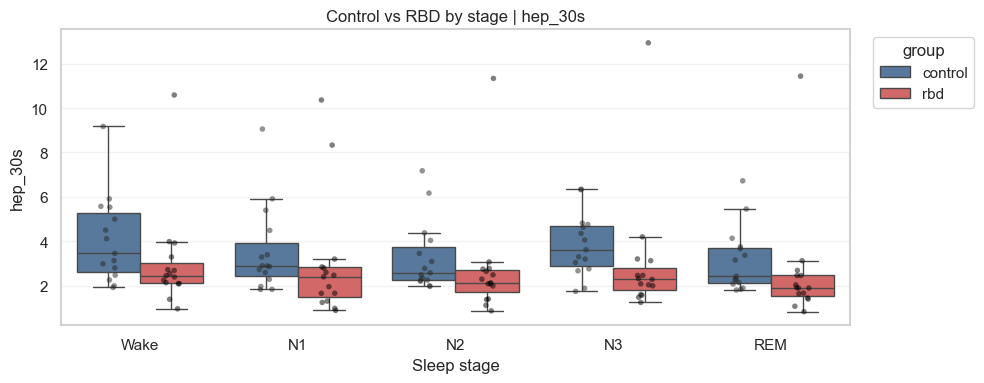


Stage-level comparison for delta_30s


,metric,n_control,n_rbd,mean_control,mean_control_ci_low,mean_control_ci_high,mean_rbd,mean_rbd_ci_low,mean_rbd_ci_high,mean_diff_control_minus_rbd,...,sd_rbd,test,statistic,p_value,effect_size,effect_name,shapiro_control_p,shapiro_rbd_p,stage,p_fdr_bh
0,delta_30s,15,15,0.3975,0.3435,0.4579,0.3108,0.2461,0.3705,0.0867,...,0.1269,welch_t,1.9393,0.0627,0.7081,cohen_d,0.0961,0.3508,Wake,0.1570
1,delta_30s,15,15,0.3571,0.2778,0.4394,0.2669,0.2128,0.3209,0.0902,...,0.1116,welch_t,1.7412,0.0942,0.6358,cohen_d,0.5206,0.4195,N1,0.1570
2,delta_30s,15,15,0.4224,0.3765,0.4658,0.3679,0.3327,0.4043,0.0545,...,0.0733,welch_t,1.8016,0.0829,0.6579,cohen_d,0.7218,0.8150,N2,0.1570
3,delta_30s,15,15,0.4798,0.4308,0.5304,0.4720,0.4284,0.5159,0.0077,...,0.0882,welch_t,0.2230,0.8252,0.0814,cohen_d,0.5291,0.8855,N3,0.9669
4,delta_30s,15,15,0.3871,0.3234,0.4616,0.3674,0.3129,0.4215,0.0198,...,0.1102,mann_whitney,114.0000,0.9669,-0.0133,rank_biserial,0.0414,0.6067,REM,0.9669


Saved: c:\Users\carlo\OneDrive - Universidade de Lisboa\Documents\GitHub\heart-lung-brain-coupling-for-RBD\Notebooks\statistics_stage_level_delta_30s.csv


C:\Users\carlo\AppData\Local\Temp\ipykernel_11884\1060146072.py:327: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=plot_df, x="stage", y=metric, hue="group", order=stage_order, hue_order=group_order, dodge=True, alpha=0.5, color="black", size=4, ax=ax)


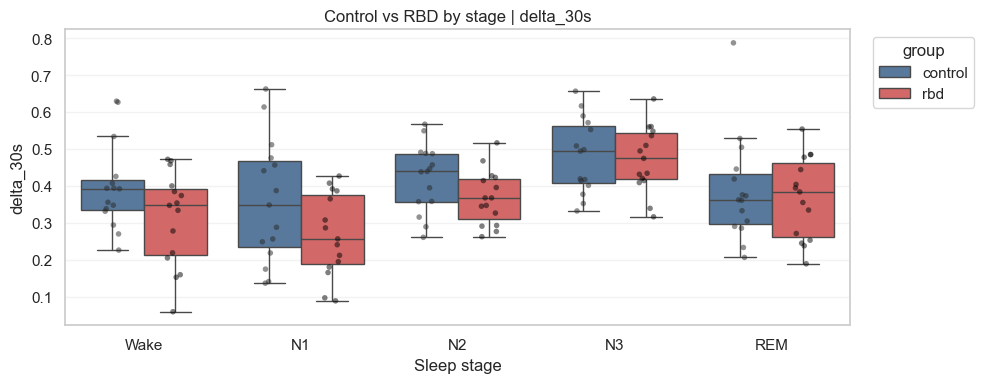

In [6]:
# Here each point is the mean of that stage within one patient.
stage_metrics = [
    col for col in stage_df.columns
    if col not in ["patient_id", "group", "stage"]
]

for metric in stage_metrics:
    print(f"\nStage-level comparison for {metric}")
    stage_stats = stage_stats_table(stage_df, metric)
    display(stage_stats.round(4))

    stage_csv = results_dir / f"statistics_stage_level_{metric}.csv"
    stage_stats.drop(columns=["p_fdr_bh"], errors="ignore").to_csv(stage_csv, index=False)
    print(f"Saved: {stage_csv}")

    plot_stage_metric(stage_df, metric, title=f"Control vs RBD by stage | {metric}")



Stage-level comparison for pearson_30s_r


,metric,n_control,n_rbd,mean_control,mean_control_ci_low,mean_control_ci_high,mean_rbd,mean_rbd_ci_low,mean_rbd_ci_high,mean_diff_control_minus_rbd,...,sd_rbd,test,statistic,p_value,effect_size,effect_name,shapiro_control_p,shapiro_rbd_p,stage,p_fdr_bh
0,pearson_30s_r,15,15,0.2339,0.1453,0.3256,0.2149,0.1337,0.2968,0.0190,...,0.1680,welch_t,0.2967,0.7689,0.1083,cohen_d,0.1088,0.5778,Wake,0.7851
1,pearson_30s_r,14,14,0.1443,-0.0564,0.3236,0.1858,0.0285,0.3431,-0.0415,...,0.3098,welch_t,-0.3207,0.7511,-0.1212,cohen_d,0.2163,0.3604,N1,0.7851
2,pearson_30s_r,15,15,0.2073,0.0926,0.3171,0.1815,0.1048,0.2535,0.0258,...,0.1518,welch_t,0.3628,0.7199,0.1325,cohen_d,0.9562,0.8584,N2,0.7851
3,pearson_30s_r,15,15,0.2636,0.1893,0.3341,0.1265,0.0288,0.2125,0.1371,...,0.1888,welch_t,2.2226,0.0350,0.8116,cohen_d,0.6328,0.0777,N3,0.1751
4,pearson_30s_r,15,15,0.1972,0.1091,0.2863,0.2155,0.1235,0.3023,-0.0183,...,0.1838,welch_t,-0.2752,0.7851,-0.1005,cohen_d,0.1764,0.1210,REM,0.7851


Saved: c:\Users\carlo\OneDrive - Universidade de Lisboa\Documents\GitHub\heart-lung-brain-coupling-for-RBD\Notebooks\statistics_stage_level_pearson_30s_r.csv


C:\Users\carlo\AppData\Local\Temp\ipykernel_11884\1060146072.py:327: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=plot_df, x="stage", y=metric, hue="group", order=stage_order, hue_order=group_order, dodge=True, alpha=0.5, color="black", size=4, ax=ax)


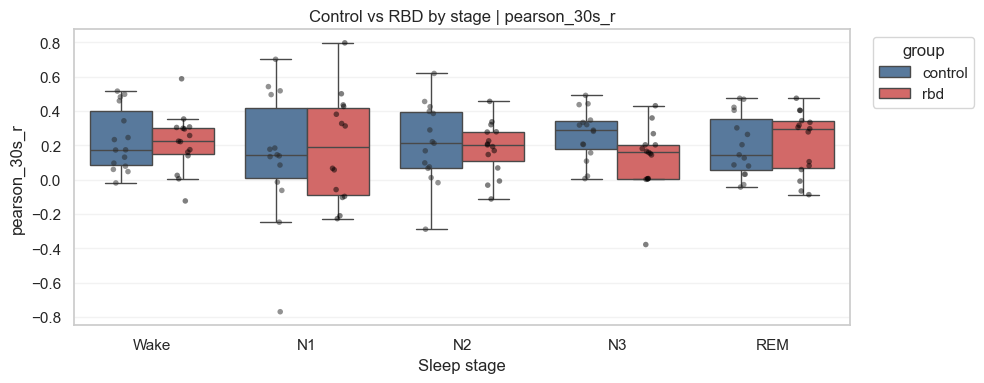


Stage-level comparison for spearman_30s_r


,metric,n_control,n_rbd,mean_control,mean_control_ci_low,mean_control_ci_high,mean_rbd,mean_rbd_ci_low,mean_rbd_ci_high,mean_diff_control_minus_rbd,...,sd_rbd,test,statistic,p_value,effect_size,effect_name,shapiro_control_p,shapiro_rbd_p,stage,p_fdr_bh
0,spearman_30s_r,15,15,0.2540,0.1932,0.3204,0.1886,0.0844,0.2800,0.0653,...,0.2041,welch_t,1.0450,0.3065,0.3816,cohen_d,0.2477,0.0514,Wake,0.5109
1,spearman_30s_r,14,14,0.2042,-0.0022,0.4102,0.1045,-0.0264,0.2526,0.0997,...,0.2748,welch_t,0.7618,0.4540,0.2879,cohen_d,0.2586,0.1929,N1,0.5675
2,spearman_30s_r,15,15,0.2362,0.1017,0.3503,0.1509,0.0711,0.2354,0.0852,...,0.1692,welch_t,1.0739,0.2934,0.3922,cohen_d,0.0751,0.6227,N2,0.5109
3,spearman_30s_r,15,15,0.2752,0.1870,0.3593,0.1530,0.0861,0.2239,0.1221,...,0.1417,welch_t,2.1003,0.0452,0.7669,cohen_d,0.9156,0.6243,N3,0.2262
4,spearman_30s_r,15,15,0.2177,0.0916,0.3443,0.1803,0.0987,0.2573,0.0374,...,0.1632,welch_t,0.4754,0.6389,0.1736,cohen_d,0.8307,0.0630,REM,0.6389


Saved: c:\Users\carlo\OneDrive - Universidade de Lisboa\Documents\GitHub\heart-lung-brain-coupling-for-RBD\Notebooks\statistics_stage_level_spearman_30s_r.csv


C:\Users\carlo\AppData\Local\Temp\ipykernel_11884\1060146072.py:327: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=plot_df, x="stage", y=metric, hue="group", order=stage_order, hue_order=group_order, dodge=True, alpha=0.5, color="black", size=4, ax=ax)


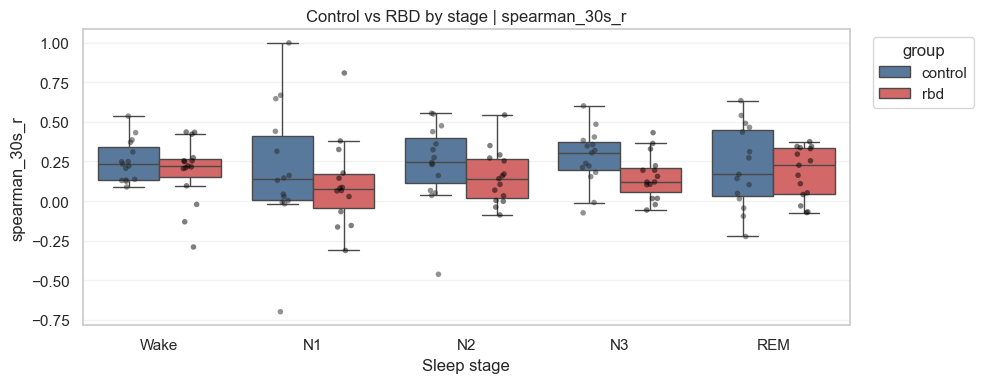

In [7]:
# 30 s correlations computed within each patient and sleep stage from hep_30s vs delta_30s.
from scipy.stats import pearsonr, spearmanr

stage_corr_columns = ["patient_id", "group", "stage", "n_valid_30s_epochs", "pearson_30s_r", "spearman_30s_r"]

stage_corr_rows = []
for (patient_id, group, stage), stage_group in epoch_df.groupby(["patient_id", "group", "stage"], observed=True):
    subset = stage_group[["hep_30s", "delta_30s"]].dropna()
    row = {
        "patient_id": patient_id,
        "group": group,
        "stage": stage,
        "n_valid_30s_epochs": int(len(subset)),
        "pearson_30s_r": np.nan,
        "spearman_30s_r": np.nan,
    }

    if len(subset) >= 3:
        x = subset["hep_30s"].to_numpy(dtype=float)
        y = subset["delta_30s"].to_numpy(dtype=float)

        if np.nanstd(x) > 0 and np.nanstd(y) > 0:
            row["pearson_30s_r"] = float(pearsonr(x, y).statistic)
            row["spearman_30s_r"] = float(spearmanr(x, y).statistic)

    stage_corr_rows.append(row)

if stage_corr_rows:
    stage_corr_30s_df = pd.DataFrame(stage_corr_rows, columns=stage_corr_columns)
    stage_corr_30s_df["stage"] = pd.Categorical(stage_corr_30s_df["stage"], categories=stage_order, ordered=True)
    stage_corr_30s_df = stage_corr_30s_df.sort_values(["group", "patient_id", "stage"]).reset_index(drop=True)
else:
    stage_corr_30s_df = pd.DataFrame(columns=stage_corr_columns)

stage_corr_metrics = ["pearson_30s_r", "spearman_30s_r"]

for metric in stage_corr_metrics:
    print(f"\nStage-level comparison for {metric}")
    stage_stats = stage_stats_table(stage_corr_30s_df, metric)
    display(stage_stats.round(4))

    stage_csv = results_dir / f"statistics_stage_level_{metric}.csv"
    stage_stats.drop(columns=["p_fdr_bh"], errors="ignore").to_csv(stage_csv, index=False)
    print(f"Saved: {stage_csv}")

    plot_stage_metric(stage_corr_30s_df, metric, title=f"Control vs RBD by stage | {metric}")
